In [ ]:
!pip install openpyxl -q
import numpy as np, pandas as pd, glob, re, os, ast, zipfile, random, math
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error, r2_score, accuracy_score,
                             classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score)
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    uploaded = files.upload()
    DATA_DIR = '/content/training_data'
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_name = next(iter(uploaded.keys()))
    with zipfile.ZipFile(zip_name) as z:
        z.extractall(DATA_DIR)
else:
    DATA_DIR = './training_data'

roots = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
BASE_DIR = Path(DATA_DIR)/roots[0] if len(roots)==1 and roots[0].startswith('training_data') else Path(DATA_DIR)
print(f'BASE_DIR: {BASE_DIR}')
for d in sorted(os.listdir(BASE_DIR)):
    p = BASE_DIR/d
    if p.is_dir(): print(f'  {d}/  ({len(os.listdir(p))} files)')

Saving training_data_v2 - Copy (3).zip to training_data_v2 - Copy (3).zip
BASE_DIR: /content/training_data/training_data_v2 - Copy (3)
  RandomCut_RP0/  (1594 files)
  RandomCut_RP0_0p5to1/  (1483 files)
  RandomCut_RP2p5/  (1594 files)
  RandomCut_RP2p5_0p5to1/  (1486 files)
  RandomCut_RP5/  (1600 files)
  RandomCut_RP5_0p5to1/  (1489 files)
  cutout_different_modal_y2/  (52 files)
  cutout_different_modal_y4/  (55 files)
  cutout_different_modal_y6/  (52 files)
  cutout_different_modal_y8/  (50 files)
  cutout_different_response_y2/  (26 files)
  cutout_different_response_y4/  (27 files)
  cutout_different_response_y6/  (26 files)
  cutout_different_response_y8/  (25 files)
  cutout_middle_modal/  (948 files)
  cutout_middle_response/  (474 files)
  cutout_randomlocation - Copy/  (1493 files)
  labels/  (1 files)
  modal_different_y2/  (54 files)
  modal_different_y4/  (58 files)
  modal_different_y6/  (52 files)
  modal_different_y8/  (52 files)
  modal_middle/  (948 files)
  repon

In [ ]:
MODAL_RESAMPLE_LEN = 256
RESPONSE_RESAMPLE_LEN = 256
N_MODES = 10
SENSOR_OFFSET_MAX = 5.0

def parse_modal_file(filepath):
    pos, modes = [], []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 11: continue
            try:
                vals = [float(v) for v in parts]
                pos.append(vals[0]); modes.append(vals[1:])
            except ValueError: continue
    if not pos: return None, None
    return np.array(pos), np.array(modes)

def parse_response_file(filepath):
    fq, am = [], []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 2: continue
            try:
                vals = [float(v) for v in parts]
                fq.append(vals[0]); am.append(vals[1])
            except ValueError: continue
    if not fq: return None, None
    return np.array(fq), np.array(am)

def parse_freq_report(filepath):
    out = np.zeros(N_MODES)
    try:
        with open(filepath, 'r') as f:
            text = f.read().strip()
        if not text: return out
        parsed = ast.literal_eval(text)
        if parsed is None: return out
        for entry in parsed:
            try:
                m_idx = int(entry[0]); f_hz = float(entry[1])
                if 1 <= m_idx <= N_MODES: out[m_idx-1] = f_hz
            except (TypeError, ValueError, IndexError): continue
    except Exception: pass
    return out

def resample_modal(pos, modes, n=MODAL_RESAMPLE_LEN):
    if pos is None or len(pos) < 4: return None
    x_new = np.linspace(pos[0], pos[-1], n)
    out = np.zeros((n, modes.shape[1]))
    for i in range(modes.shape[1]):
        out[:, i] = interp1d(pos, modes[:, i], kind='linear', fill_value='extrapolate')(x_new)
    return out

def resample_response(fq, am, n=RESPONSE_RESAMPLE_LEN):
    if fq is None or len(fq) < 4: return None
    x_new = np.linspace(fq[0], fq[-1], n)
    return interp1d(fq, am, kind='linear', fill_value='extrapolate')(x_new)

print('Parsers ready.')

Parsers ready.


In [ ]:
def extract_beam_size(fname):
    m = re.search(r'(\d+by\d+mm)', fname)
    return m.group(1) if m else None

def _try_freq(folder, prefix):
    cand = list(Path(folder).glob(f'{prefix}*_FrequencyReport.txt'))
    return parse_freq_report(str(cand[0])) if cand else np.zeros(N_MODES)

def load_old_middle():
    out = []
    for cm in glob.glob(str(BASE_DIR/'cutout_middle_modal'/'*.rpt')):
        size = extract_beam_size(os.path.basename(cm))
        if not size: continue
        cr = str(BASE_DIR/'cutout_middle_response'/f'Cutout_10_0_1_{size}_Response.rpt')
        if not os.path.exists(cr): continue
        pos, modes = parse_modal_file(cm); fq, am = parse_response_file(cr)
        m_rs, r_rs = resample_modal(pos, modes), resample_response(fq, am)
        if m_rs is None or r_rs is None: continue
        freqs = _try_freq(BASE_DIR/'cutout_middle_modal', f'Cutout_10_0_1_{size}')
        out.append(dict(
            modal=m_rs, response=r_rs, freqs=freqs, damaged=1,
            Dx=10.0, Dy=0.0, radius=1.0,
            source='old_middle_dam', sensor_offset=0.0, size=size,
            filename=os.path.basename(cm)
        ))

        rm = str(BASE_DIR/'modal_middle'/f'ReferenceBeam-{size}-Modal-EdgeDisplacement.rpt')
        rr = str(BASE_DIR/'reponse_middle'/f'ReferenceBeam-{size}_Response.rpt')
        if os.path.exists(rm) and os.path.exists(rr):
            pos, modes = parse_modal_file(rm); fq, am = parse_response_file(rr)
            m_rs, r_rs = resample_modal(pos, modes), resample_response(fq, am)
            if m_rs is not None and r_rs is not None:
                freqs = _try_freq(BASE_DIR/'modal_middle', f'ReferenceBeam-{size}')
                out.append(dict(
                    modal=m_rs, response=r_rs, freqs=freqs, damaged=0,
                    Dx=0.0, Dy=0.0, radius=0.0,
                    source='old_middle_ref', sensor_offset=0.0, size=size,
                    filename=os.path.basename(rm)
                ))
    return out

def load_old_different_y():
    out = []
    cfgs = {
        'y2': dict(rp='RP1_1p25', off=1.25, cm='cutout_different_modal_y2', cr='cutout_different_response_y2',
                   rm='modal_different_y2', rr='reponse_different_y2'),
        'y4': dict(rp='RP1_2p5',  off=2.5,  cm='cutout_different_modal_y4', cr='cutout_different_response_y4',
                   rm='modal_different_y4', rr='response_different_y4'),
        'y6': dict(rp='RP1_3p75', off=3.75, cm='cutout_different_modal_y6', cr='cutout_different_response_y6',
                   rm='modal_different_y6', rr='response_different_y6'),
        'y8': dict(rp='RP1_5p0',  off=5.0,  cm='cutout_different_modal_y8', cr='cutout_different_response_y8',
                   rm='modal_different_y8', rr='response_difference_y8'),
    }
    for tag, c in cfgs.items():
        cm_dir = BASE_DIR/c['cm']
        if not cm_dir.exists(): continue
        for cm in glob.glob(str(cm_dir/'*.rpt')):
            size = extract_beam_size(os.path.basename(cm))
            if not size: continue
            cr_p = str(BASE_DIR/c['cr']/f"Cutout_{c['rp']}-10_0_1_{size}_Response.rpt")
            if not os.path.exists(cr_p): continue
            pos, modes = parse_modal_file(cm); fq, am = parse_response_file(cr_p)
            m_rs, r_rs = resample_modal(pos, modes), resample_response(fq, am)
            if m_rs is None or r_rs is None: continue
            freqs = _try_freq(cm_dir, f"Cutout_{c['rp']}-10_0_1_{size}")
            out.append(dict(
                modal=m_rs, response=r_rs, freqs=freqs, damaged=1,
                Dx=10.0, Dy=0.0, radius=1.0,
                source=f'old_{tag}_dam', sensor_offset=c['off'], size=size,
                filename=os.path.basename(cm)
            ))

        rm_dir = BASE_DIR/c['rm']
        rr_dir = BASE_DIR/c['rr']
        if rm_dir.exists() and rr_dir.exists():
            for rm in glob.glob(str(rm_dir/'*.rpt')):
                size = extract_beam_size(os.path.basename(rm))
                if not size: continue
                rr_p = str(rr_dir/f"ReferenceBeam-{c['rp']}-{size}_Response.rpt")
                if not os.path.exists(rr_p):
                    _cands = [p for p in glob.glob(str(rr_dir/'*.rpt')) if size in os.path.basename(p)]
                    if not _cands: continue
                    rr_p = _cands[0]
                pos, modes = parse_modal_file(rm); fq, am = parse_response_file(rr_p)
                m_rs, r_rs = resample_modal(pos, modes), resample_response(fq, am)
                if m_rs is None or r_rs is None: continue

                freqs = _try_freq(rm_dir, f"ReferenceBeam-{c['rp']}-{size}")
                if freqs.sum() == 0:
                    freqs = _try_freq(rm_dir, f'ReferenceBeam-{size}')
                out.append(dict(
                    modal=m_rs, response=r_rs, freqs=freqs, damaged=0,
                    Dx=0.0, Dy=0.0, radius=0.0,
                    source=f'old_{tag}_ref', sensor_offset=c['off'], size=size,
                    filename=os.path.basename(rm)
                ))

    return out


def load_old_random_location():
    import openpyxl
    out = []
    xlsx = list((BASE_DIR/'labels').glob('*.xlsx')) if (BASE_DIR/'labels').exists() else []
    if not xlsx:
        print('  old_random_location: no xlsx, skipping'); return out
    wb = openpyxl.load_workbook(str(xlsx[0]), data_only=True); ws = wb.active
    labels = {}
    for i, row in enumerate(ws.iter_rows(min_row=2, values_only=True), start=1):
        sr = row[0] if row[0] is not None else i
        if row[1] is None or row[2] is None or row[3] is None: continue
        try: labels[int(sr)] = (float(row[1]), float(row[2]), float(row[3]))
        except: continue
    rdir = BASE_DIR/'cutout_randomlocation - Copy'
    if not rdir.exists(): return out
    for n, (Dx, Dy, R) in labels.items():
        mf = rdir/f'Frequency_Analysis_{n}-Modal-EdgeDisplacement.rpt'
        rf = rdir/f'Frequency_Analysis_{n}_Response.rpt'
        if not (mf.exists() and rf.exists()): continue
        pos, modes = parse_modal_file(str(mf)); fq, am = parse_response_file(str(rf))
        m_rs, r_rs = resample_modal(pos, modes), resample_response(fq, am)
        if m_rs is None or r_rs is None: continue
        freqs = _try_freq(rdir, f'Frequency_Analysis_{n}')
        out.append(dict(
            modal=m_rs, response=r_rs, freqs=freqs, damaged=1,
            Dx=Dx, Dy=Dy, radius=R,
            source='old_random', sensor_offset=0.0, size=None,
            filename=os.path.basename(str(mf))
        ))

    return out

print('Old loaders ready.')


Old loaders ready.


In [ ]:
import ast

NEW_FOLDER_OFFSET = {
    'RandomCut_RP0': 0.0, 'RandomCut_RP0_0p5to1': 0.0,
    'RandomCut_RP2p5': 2.5, 'RandomCut_RP2p5_0p5to1': 2.5,
    'RandomCut_RP5':  5.0, 'RandomCut_RP5_0p5to1':  5.0,
}
RP_PREFIX = {'RandomCut_RP0':'RP_0', 'RandomCut_RP0_0p5to1':'RP_0',
             'RandomCut_RP2p5':'RP_2p5', 'RandomCut_RP2p5_0p5to1':'RP_2p5',
             'RandomCut_RP5':'RP_5', 'RandomCut_RP5_0p5to1':'RP_5'}


def _parse_master_py(folder):

    pys = list(folder.glob('*.py'))
    if not pys:
        return {}
    text = pys[0].read_text(encoding='utf-8', errors='ignore')


    m = re.search(
        r'\b(?:cutouts|cutout_list|cutoutList|cases|samples|jobs)\s*=\s*\[',
        text
    )
    if m:
        start = m.end() - 1
        depth = 0
        end_idx = None
        for i in range(start, len(text)):
            c = text[i]
            if c == '[': depth += 1
            elif c == ']':
                depth -= 1
                if depth == 0:
                    end_idx = i + 1
                    break
        if end_idx is not None:
            try:
                arr = ast.literal_eval(text[start:end_idx])
                return {int(d['num']): (float(d['Dx']),
                                         float(d['Dy']),
                                         float(d['radius']))
                        for d in arr
                        if all(k in d for k in ('num', 'Dx', 'Dy', 'radius'))}
            except Exception as e:
                print(f'Loaded')


    out = {}
    pat = re.compile(
        r'["\']num["\']\s*:\s*(-?\d+)\s*,\s*'
        r'["\']Dx["\']\s*:\s*(-?[\d.]+)\s*,\s*'
        r'["\']Dy["\']\s*:\s*(-?[\d.]+)\s*,\s*'
        r'["\']radius["\']\s*:\s*(-?[\d.]+)'
    )
    for n, dx, dy, r in pat.findall(text):
        out[int(n)] = (float(dx), float(dy), float(r))
    return out


def load_new_randomcut():
    out = []
    for fname, offset in NEW_FOLDER_OFFSET.items():
        folder = BASE_DIR / fname
        if not folder.exists():
            continue
        labels = _parse_master_py(folder)
        if not labels:
            print(f'  {fname}: no labels'); continue
        prefix = RP_PREFIX[fname]
        n_label = len(labels)
        n_loaded = 0
        for n in sorted(labels.keys()):
            mf = folder / f'{prefix}_Cut_{n}-Modal-EdgeDisplacement.rpt'
            rf = folder / f'{prefix}_Cut_{n}_Response.rpt'
            ff = folder / f'{prefix}_Cut_{n}_FrequencyReport.txt'
            if not (mf.exists() and rf.exists()):
                continue
            pos, modes = parse_modal_file(str(mf))
            fq, am     = parse_response_file(str(rf))
            m_rs = resample_modal(pos, modes)
            r_rs = resample_response(fq, am)
            if m_rs is None or r_rs is None:
                continue
            freqs = parse_freq_report(str(ff)) if ff.exists() else np.zeros(N_MODES)
            Dx, Dy, R = labels[n]
            out.append(dict(
                modal=m_rs, response=r_rs, freqs=freqs, damaged=1,
                Dx=Dx, Dy=Dy, radius=R,
                source='new', sensor_offset=offset, size=None,
                filename=mf.name,
            ))
            n_loaded += 1

    return out

print('New loader ready.')

New loader ready.


In [ ]:
samples = load_old_middle() + load_old_different_y() + load_old_random_location() + load_new_randomcut()
print(f'\nTotal raw samples: {len(samples)}')

def in_range(s):
    if not s['damaged']: return True
    return -50 <= s['Dx'] <= 50 and -5 <= s['Dy'] <= 5 and 0.0 <= s['radius'] <= 1.5
before = len(samples)
samples = [s for s in samples if in_range(s)]
filenames = np.array([s.get('filename', '') for s in samples])

freqs_arr = np.array([s['freqs'] for s in samples])
healthy_mask = np.array([s['damaged']==0 for s in samples])
valid_freq = (freqs_arr.sum(axis=1) > 0)
hb_mask = healthy_mask & valid_freq
HEALTHY_FREQ_BASELINE = freqs_arr[hb_mask].mean(axis=0) if hb_mask.sum() else np.zeros(N_MODES)
print(f'  healthy freq baseline computed from {hb_mask.sum()} samples')

N = len(samples)
beam_pos = np.linspace(0, 1, MODAL_RESAMPLE_LEN)

def _calculate_curvature(modal):

    out = np.zeros_like(modal, dtype=np.float32)
    for k in range(modal.shape[-1]):
        out[..., k] = np.gradient(np.gradient(modal[..., k], axis=-1), axis=-1)
    return out

def _delta_freqs(freqs, baseline):

    d = (freqs - baseline[None, :]).astype(np.float32)
    d[freqs.sum(axis=1) == 0] = 0.0
    return d

X_modal_raw    = np.zeros((N, MODAL_RESAMPLE_LEN, N_MODES), np.float32)
X_response_raw = np.zeros((N, RESPONSE_RESAMPLE_LEN, 1),    np.float32)
y_class  = np.zeros(N, np.int32)
y_loc    = np.zeros((N,2), np.float32)
y_radius = np.zeros(N, np.float32)
sources    = np.array([s['source'] for s in samples])
beam_sizes = np.array([s.get('size') if s.get('size') else '' for s in samples])
sensor_off = np.array([s['sensor_offset'] for s in samples], np.float32)

for i, s in enumerate(samples):
    X_modal_raw[i]        = s['modal']
    X_response_raw[i,:,0] = s['response']
    y_class[i]            = s['damaged']
    y_loc[i]              = [s['Dx'], s['Dy']]
    y_radius[i]           = s['radius']

MAX_MODAL_AMP_TRAIN = float(np.nanmax(np.abs(X_modal_raw)))
MAX_RESP_AMP_TRAIN  = float(np.nanmax(np.abs(X_response_raw)))
X_modal_raw    = np.nan_to_num(X_modal_raw,    nan=0.0, posinf=0.0, neginf=0.0)
X_response_raw = np.nan_to_num(X_response_raw, nan=0.0, posinf=0.0, neginf=0.0)

def per_sample_normalize_modal(modal):

    out = modal.copy()
    for m in range(N_MODES):
        norm = np.linalg.norm(out[..., m], axis=-1, keepdims=True) + 1e-12
        out[..., m] = out[..., m] / norm
    return out

def per_sample_normalize_response(resp):

    norm = np.linalg.norm(resp, axis=-2, keepdims=True) + 1e-12
    return resp / norm

X_modal    = per_sample_normalize_modal(X_modal_raw)
X_response = per_sample_normalize_response(X_response_raw)

X_curv = _calculate_curvature(X_modal)

healthy_baseline_modal = X_modal[hb_mask].mean(axis=0) if hb_mask.sum() else X_modal.mean(axis=0)

delta_freqs = _delta_freqs(freqs_arr, HEALTHY_FREQ_BASELINE)

N_EXT_CH = N_MODES*2 + 1 + N_MODES
X_modal_extended = np.zeros((N, MODAL_RESAMPLE_LEN, N_EXT_CH), np.float32)
X_modal_extended[:, :, :N_MODES]          = X_modal
X_modal_extended[:, :, N_MODES:2*N_MODES] = X_curv
X_modal_extended[:, :, 2*N_MODES]         = beam_pos[None, :]
X_modal_extended[:, :, 2*N_MODES+1:]      = delta_freqs[:, None, :]
print(f'X_modal_extended shape: {X_modal_extended.shape} ')

def build_spatial(X_modal_arr, freqs_arr, sensor_off_arr, hb_modal, hb_freq):
    Nlocal = X_modal_arr.shape[0]
    curv   = _calculate_curvature(X_modal_arr)
    base = np.zeros((Nlocal, 32), np.float32)
    for i in range(Nlocal):
        c = curv[i]
        for k in range(N_MODES):
            ac = np.abs(c[:, k]); pk = int(np.argmax(ac))
            base[i, k*3]   = beam_pos[pk]
            base[i, k*3+1] = ac[pk]
            base[i, k*3+2] = (ac*beam_pos).sum()/(ac.sum()+1e-12)
        tot = np.abs(c).sum(axis=1)
        base[i, 30] = (tot*beam_pos).sum()/(tot.sum()+1e-12)
        base[i, 31] = sensor_off_arr[i] / SENSOR_OFFSET_MAX
    delta = _delta_freqs(freqs_arr, hb_freq)
    mt = X_modal_arr.transpose(0,2,1)
    tkeo = np.zeros_like(mt); tkeo[..., 1:-1] = mt[..., 1:-1]**2 - mt[..., :-2]*mt[..., 2:]
    tkeo_peak = np.argmax(np.abs(tkeo), axis=-1) / float(MODAL_RESAMPLE_LEN-1)
    half = MODAL_RESAMPLE_LEN//2
    le = (np.abs(mt[..., :half])**2).sum(-1); re_ = (np.abs(mt[..., half:])**2).sum(-1)
    asym = (re_ - le) / (le + re_ + 1e-12)
    res = X_modal_arr - hb_modal[None, :, :]
    res_norm = np.linalg.norm(res, axis=1)
    return np.concatenate([base, delta, tkeo_peak, asym, res_norm], axis=1).astype(np.float32)

def compute_dx_extra(X_modal_scaled):
    Nlocal = X_modal_scaled.shape[0]
    curv   = _calculate_curvature(X_modal_scaled)
    out = np.zeros((Nlocal, 6), np.float32)
    for i in range(Nlocal):
        c  = curv[i]
        ac = np.abs(c)
        m1_peak = beam_pos[int(np.argmax(ac[:, 0]))]
        m2_peak = beam_pos[int(np.argmax(ac[:, 1]))]
        m3_peak = beam_pos[int(np.argmax(ac[:, 2]))]
        out[i, 0] = m1_peak
        out[i, 1] = m1_peak / (m2_peak + 1e-6)
        out[i, 2] = m1_peak / (m3_peak + 1e-6)
        out[i, 3] = (ac[:, 0] * beam_pos).sum() / (ac[:, 0].sum() + 1e-12)
        out[i, 4] = (c[:, 0]**2).sum()
        out[i, 5] = (c[:, 0]**2).sum() / ((c[:, 1]**2).sum() + 1e-6)
    return out

X_spatial = build_spatial(X_modal, freqs_arr, sensor_off, healthy_baseline_modal, HEALTHY_FREQ_BASELINE)
N_SPATIAL = X_spatial.shape[1]
print(f'X_modal {X_modal.shape}')
print(f'X_modal_ext {X_modal_extended.shape}')
print(f'X_response {X_response.shape}')
print(f'X_spatial {X_spatial.shape} 72')
print(f'y_class {y_class.shape}: damaged={(y_class==1).sum()}, healthy={(y_class==0).sum()}')

Loaded

Total raw samples: 4736
  healthy freq baseline computed from 581 samples
X_modal_extended shape: (4736, 256, 31) 
X_modal (4736, 256, 10)
X_modal_ext (4736, 256, 31)
X_response (4736, 256, 1)
X_spatial (4736, 72) 72
y_class (4736,): damaged=4155, healthy=581


In [ ]:
_new_ref_sources = {'old_y2_ref', 'old_y4_ref', 'old_y6_ref', 'old_y8_ref'}
_scaler_fit_mask = ~np.isin(sources, list(_new_ref_sources))

modal_scalers = []
for m in range(N_MODES):
    sc = StandardScaler()
    sc.fit(X_modal[_scaler_fit_mask, :, m])
    X_modal[:, :, m] = sc.transform(X_modal[:, :, m])
    modal_scalers.append(sc)

modal_ext_scalers = []
for m in range(X_modal_extended.shape[2]):
    sc = StandardScaler()
    sc.fit(X_modal_extended[_scaler_fit_mask, :, m])
    X_modal_extended[:, :, m] = sc.transform(X_modal_extended[:, :, m])
    modal_ext_scalers.append(sc)

resp_scaler = StandardScaler()
_resp_flat = X_response.reshape(N, -1)
resp_scaler.fit(_resp_flat[_scaler_fit_mask])
X_response = resp_scaler.transform(_resp_flat).reshape(N, RESPONSE_RESAMPLE_LEN, 1)

_dx_extra_all = compute_dx_extra(X_modal)
X_spatial = np.concatenate([X_spatial, _dx_extra_all], axis=1)
N_SPATIAL = X_spatial.shape[1]

spatial_scaler = StandardScaler()
spatial_scaler.fit(X_spatial[_scaler_fit_mask])
X_spatial = spatial_scaler.transform(X_spatial)

for arr in [X_modal, X_modal_extended, X_response, X_spatial]:
    np.nan_to_num(arr, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

reg_fit = (y_class==1) & np.isin(sources, ['new', 'old_random'])
loc_scaler = StandardScaler().fit(y_loc[reg_fit])
rad_scaler = StandardScaler().fit(y_radius[reg_fit].reshape(-1,1))
y_loc_scaled = loc_scaler.transform(y_loc)
y_radius_scaled = rad_scaler.transform(y_radius.reshape(-1,1)).flatten()
np.nan_to_num(y_loc_scaled, copy=False); _u = np.nan_to_num(y_radius_scaled, copy=False)

Comparison
    Healthy ref  idx=1, source=np.str_('old_middle_ref'), size=np.str_('396by10mm')
    Cutout       idx=0, source=np.str_('old_middle_dam'), size=np.str_('396by10mm'), label=(Dx=10.0, Dy=0.0, r=1.00)


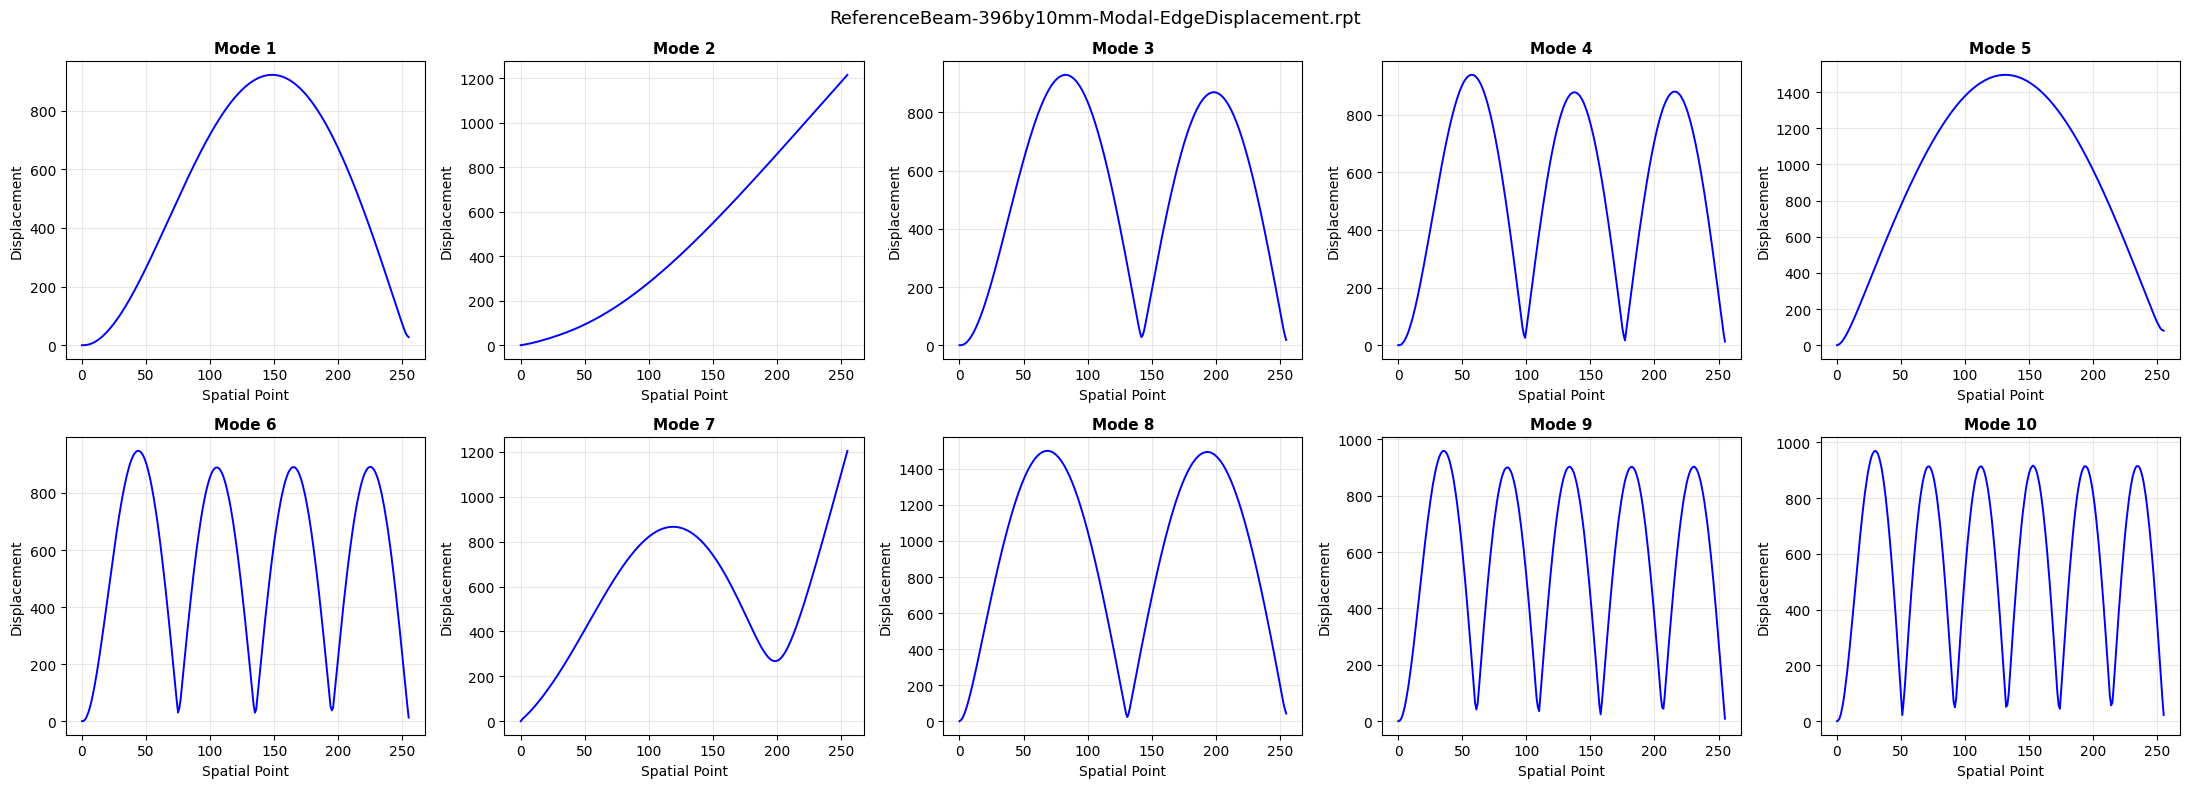

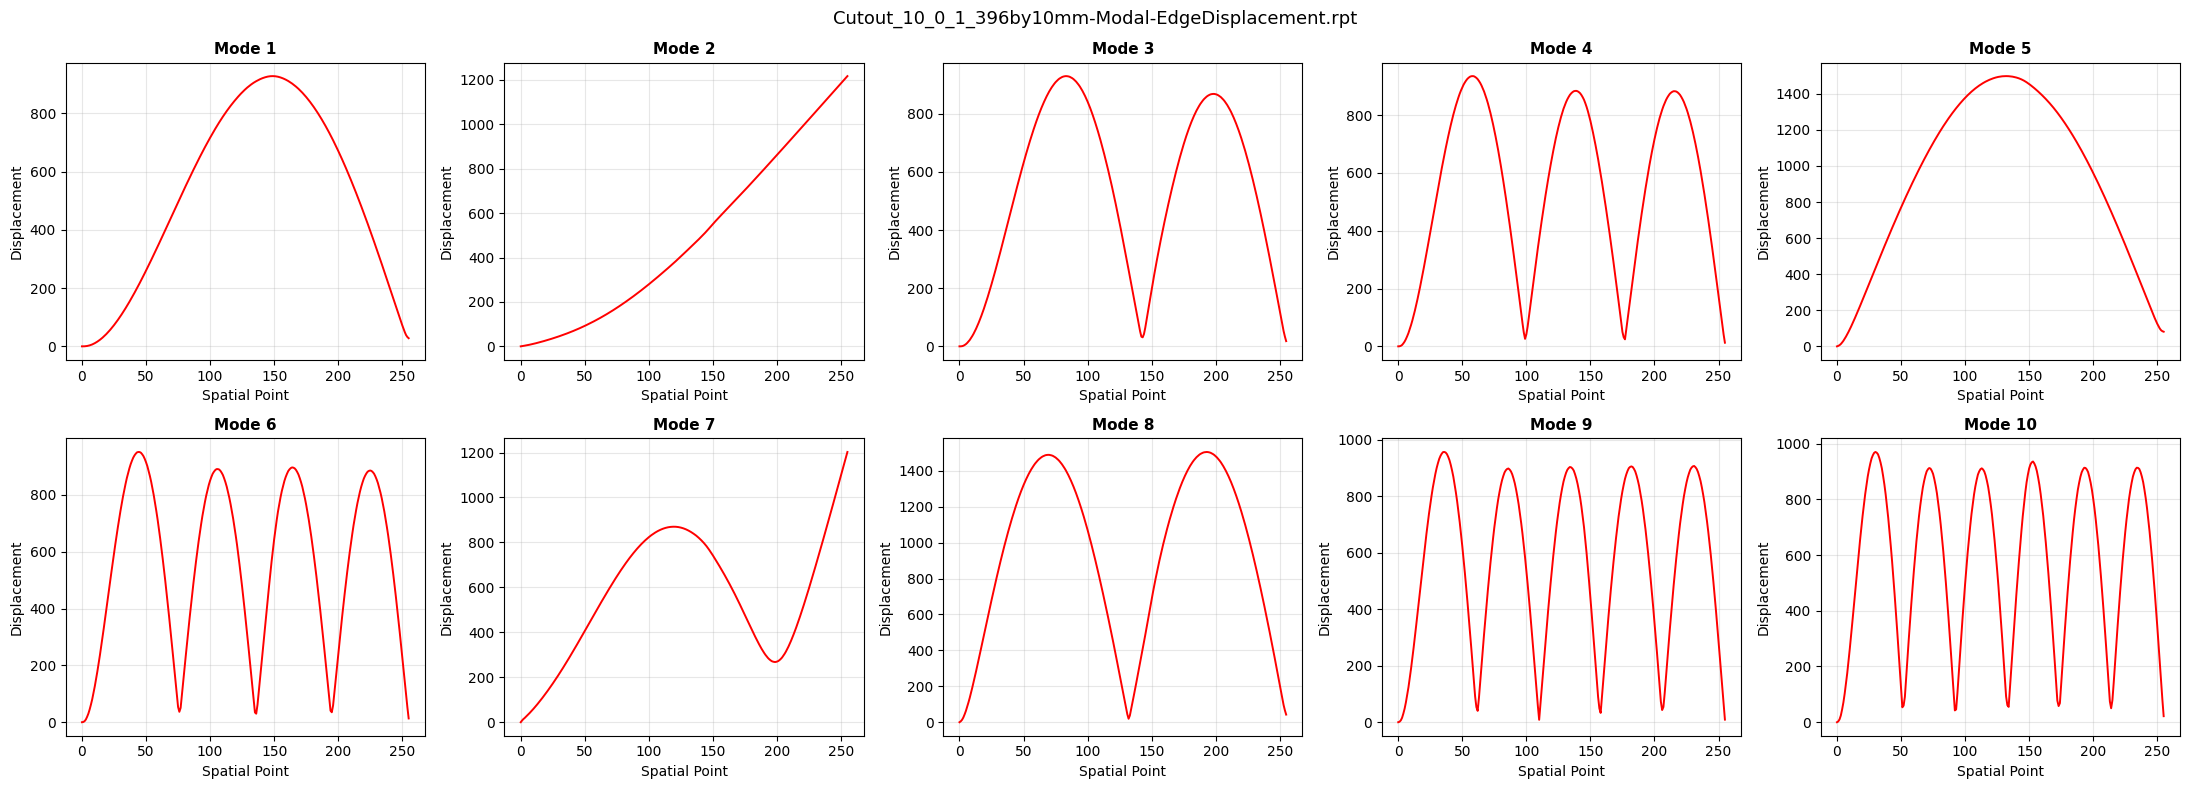

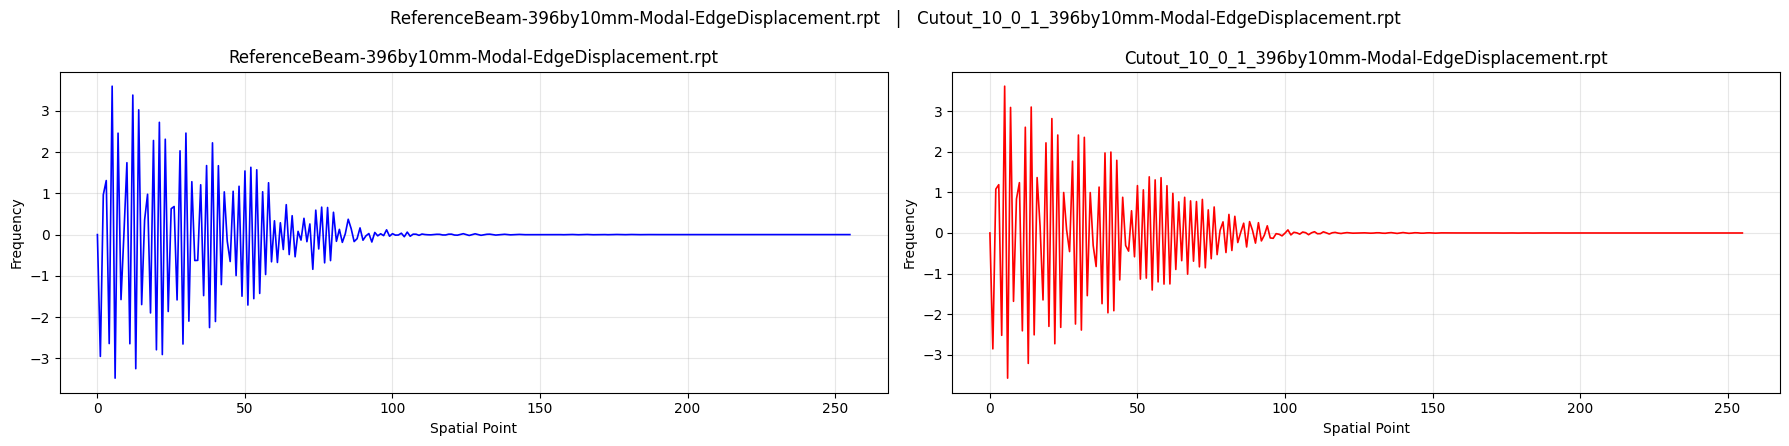

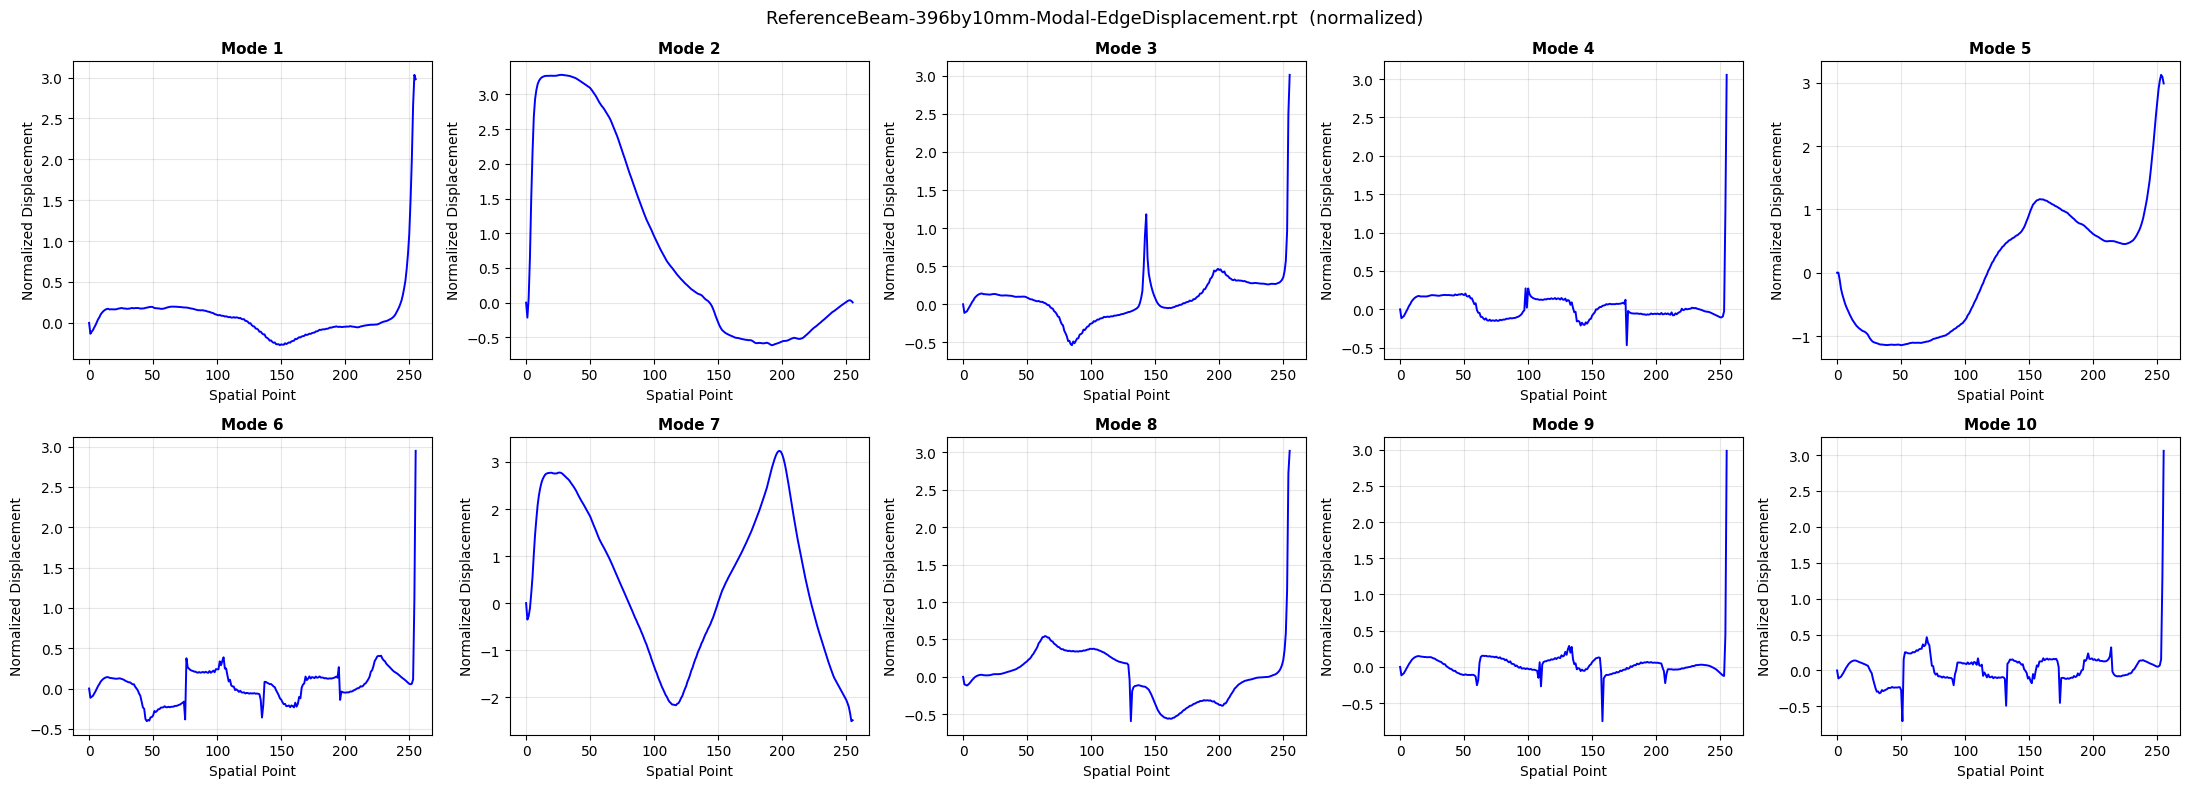

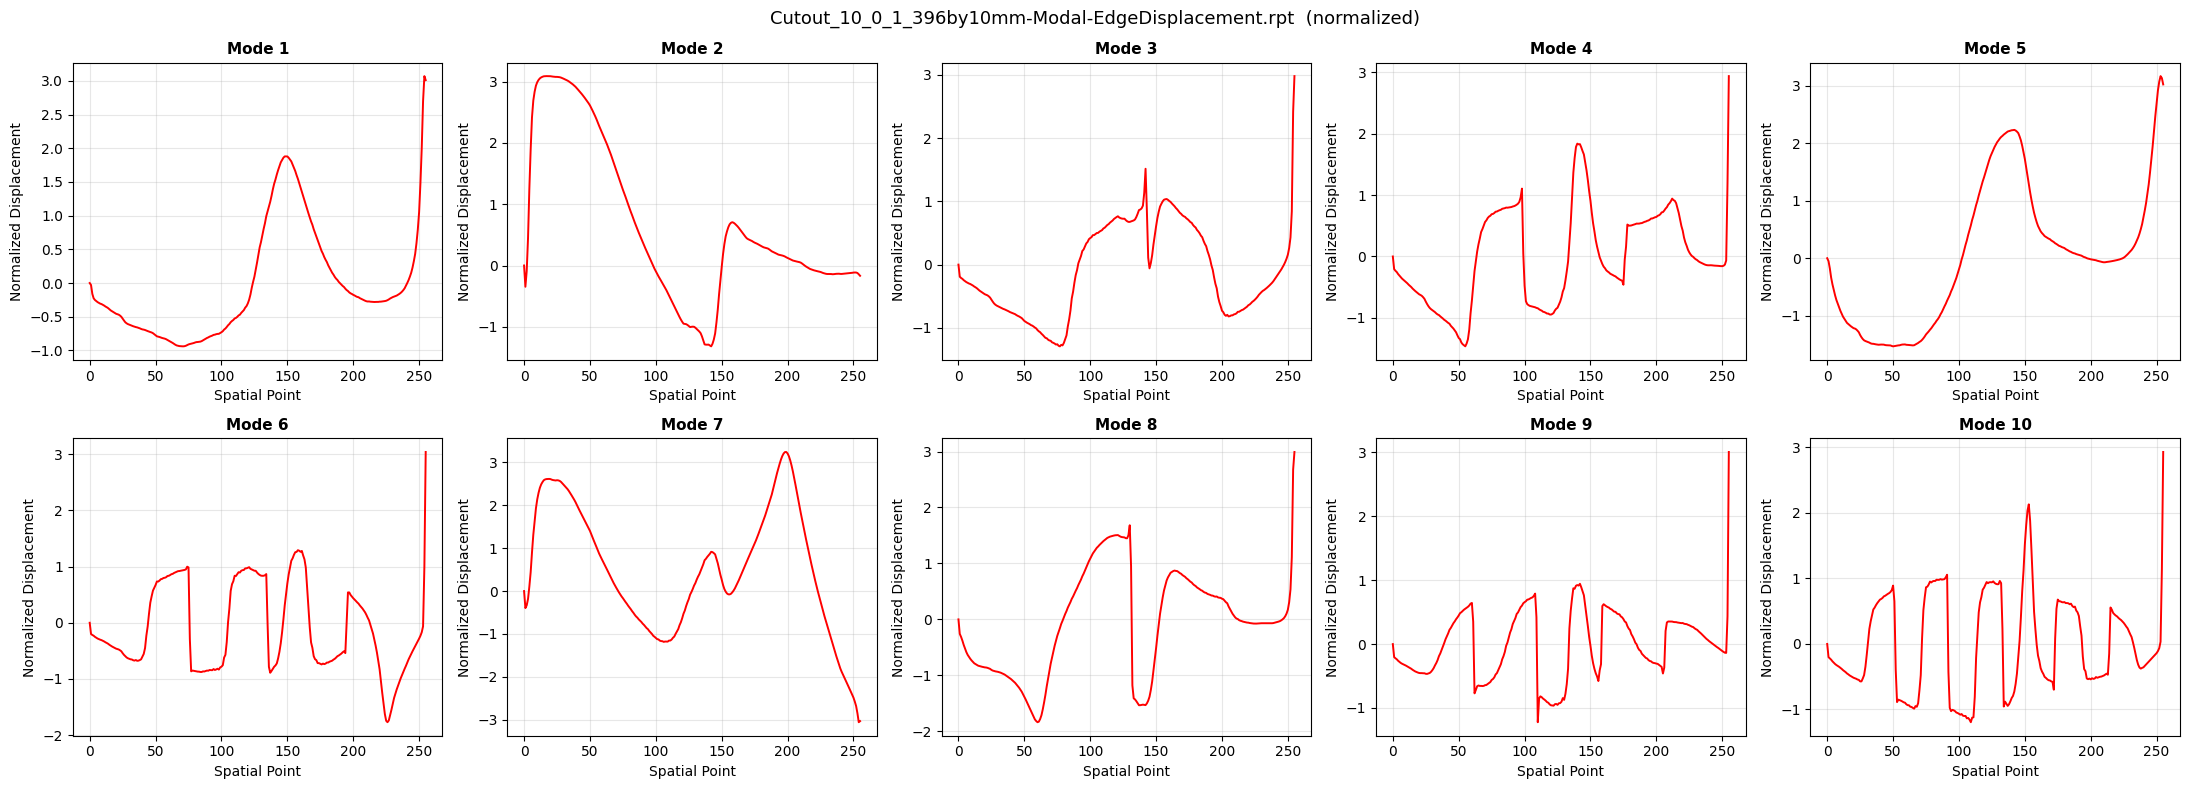

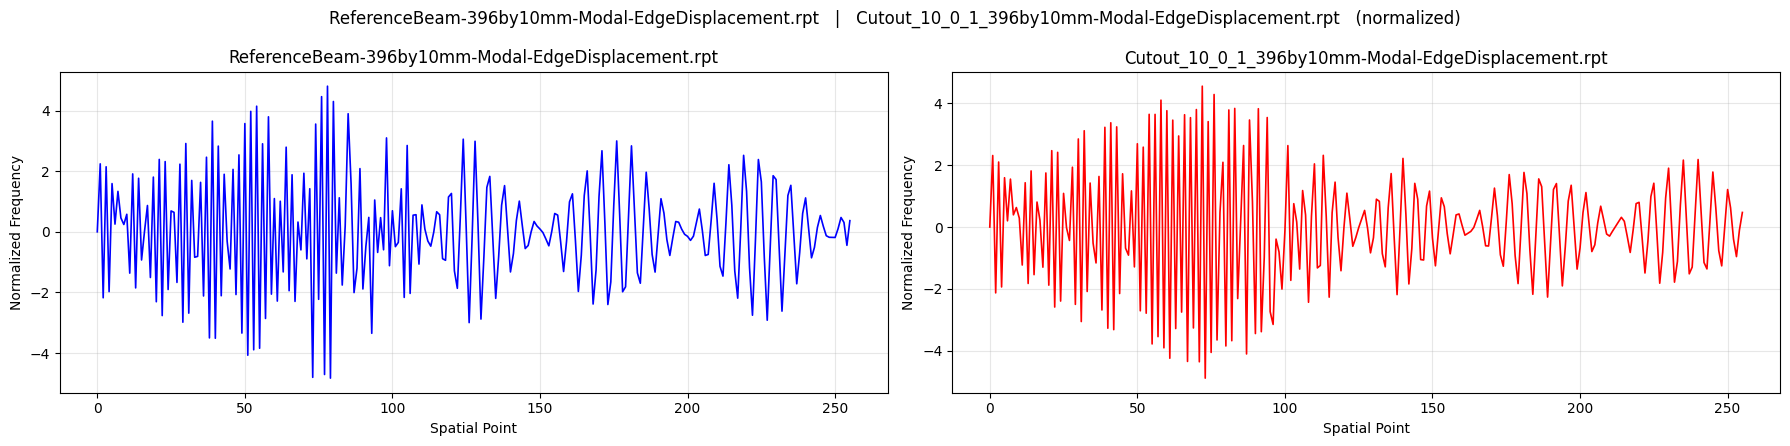

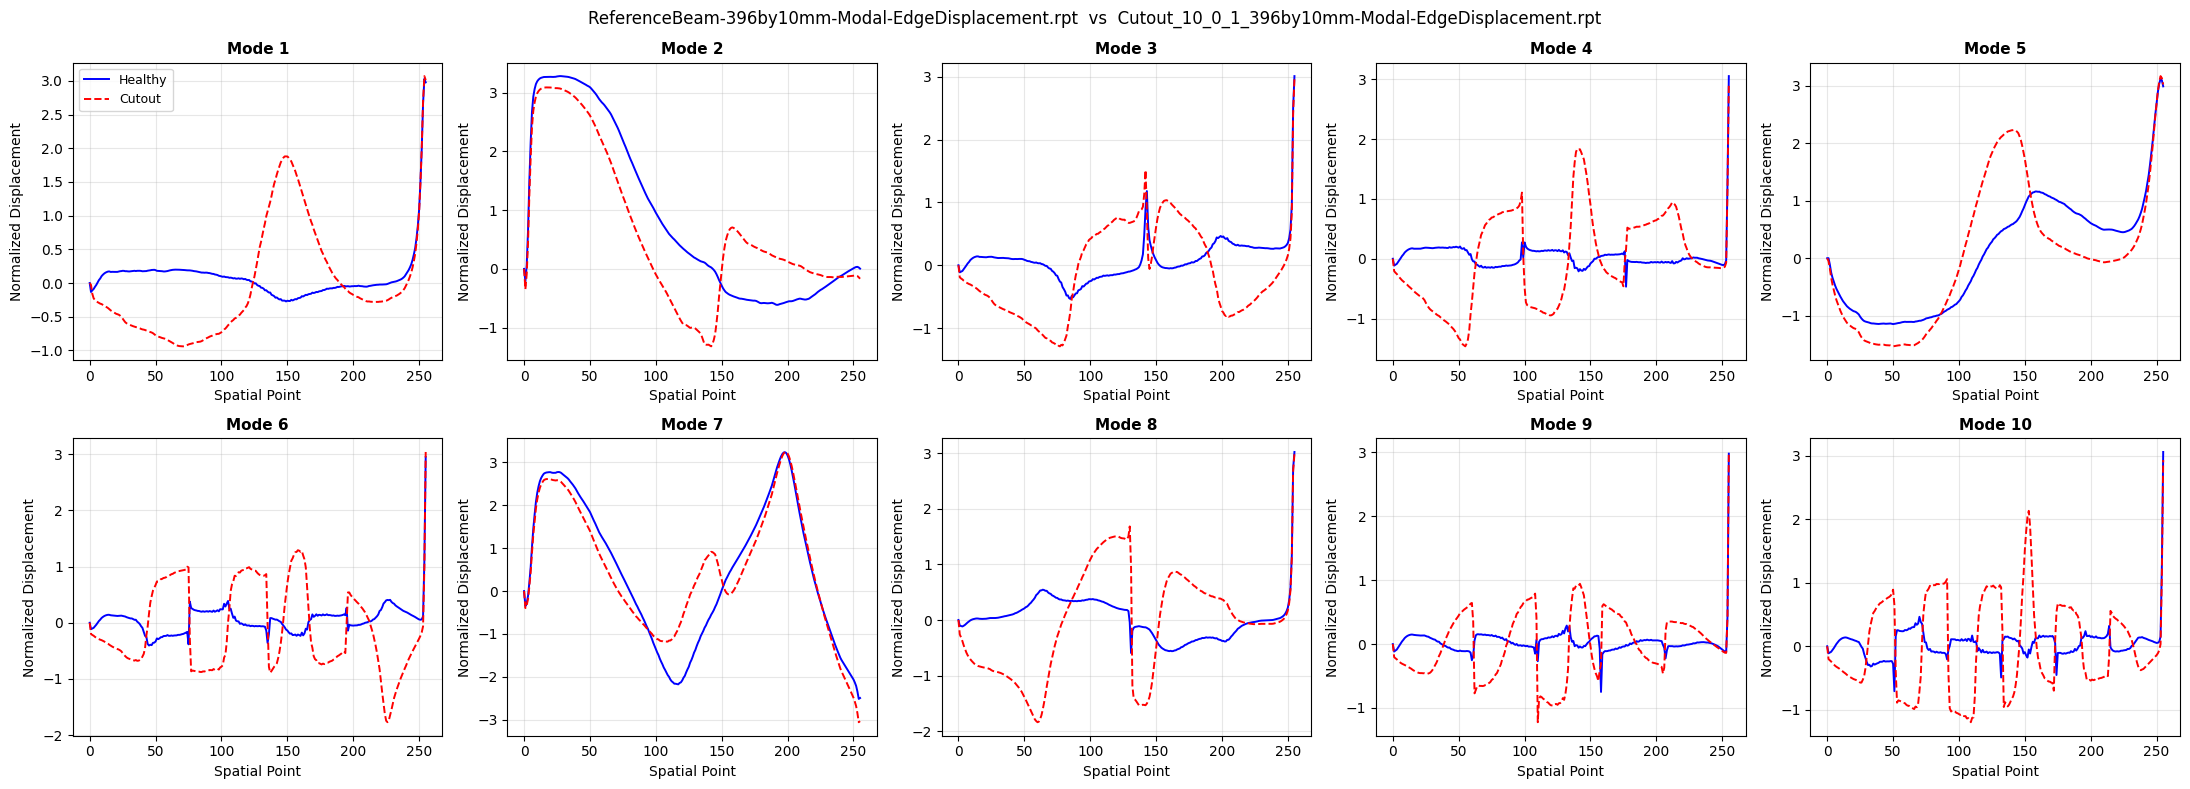

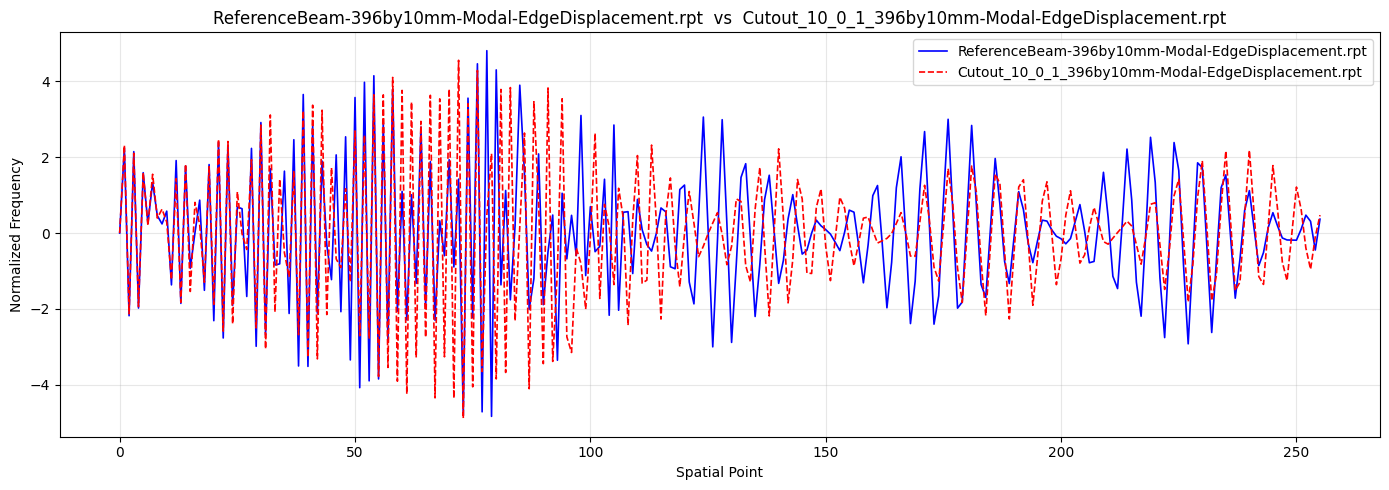

In [ ]:
import random
random.seed(42)

healthy_pool = np.where((y_class == 0) & (sources == 'old_middle_ref'))[0]
cutout_pool  = np.where((y_class == 1) & (sources == 'old_middle_dam'))[0]
healthy_sizes = set(beam_sizes[healthy_pool]) - {''}
cutout_sizes  = set(beam_sizes[cutout_pool])  - {''}
common_sizes  = sorted(healthy_sizes & cutout_sizes)
print(f'Comparison')

if not common_sizes:
    print('No matching beam sizes')
else:
    chosen_size = random.choice(common_sizes)
    h_candidates = healthy_pool[beam_sizes[healthy_pool] == chosen_size]
    d_candidates = cutout_pool [beam_sizes[cutout_pool]  == chosen_size]
    h_idx = int(random.choice(h_candidates))
    d_idx = int(random.choice(d_candidates))

    print(f'    Healthy ref  idx={h_idx}, source={sources[h_idx]!r}, size={beam_sizes[h_idx]!r}')
    print(f'    Cutout       idx={d_idx}, source={sources[d_idx]!r}, size={beam_sizes[d_idx]!r}, '
          f'label=(Dx={y_loc[d_idx,0]:.1f}, Dy={y_loc[d_idx,1]:.1f}, r={y_radius[d_idx]:.2f})')
    h_fname = f'ReferenceBeam-{chosen_size}-Modal-EdgeDisplacement.rpt'
    d_fname = f'Cutout_10_0_1_{chosen_size}-Modal-EdgeDisplacement.rpt'

    h_modal_raw  = X_modal_raw[h_idx]
    d_modal_raw  = X_modal_raw[d_idx]
    h_resp_raw   = X_response_raw[h_idx, :, 0]
    d_resp_raw   = X_response_raw[d_idx, :, 0]
    h_modal_norm = X_modal[h_idx]
    d_modal_norm = X_modal[d_idx]
    h_resp_norm  = X_response[h_idx, :, 0]
    d_resp_norm  = X_response[d_idx, :, 0]
    x_axis = np.arange(MODAL_RESAMPLE_LEN)

    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    fig.suptitle(h_fname, fontsize=13)
    for i in range(N_MODES):
        ax = axes[i // 5, i % 5]
        ax.plot(x_axis, h_modal_raw[:, i], 'b-', linewidth=1.4)
        ax.set_title(f'Mode {i+1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Spatial Point'); ax.set_ylabel('Displacement'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    fig.suptitle(d_fname, fontsize=13)
    for i in range(N_MODES):
        ax = axes[i // 5, i % 5]
        ax.plot(x_axis, d_modal_raw[:, i], 'r-', linewidth=1.4)
        ax.set_title(f'Mode {i+1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Spatial Point'); ax.set_ylabel('Displacement'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
    fig.suptitle(f'{h_fname}   |   {d_fname}', fontsize=12)
    axes[0].plot(np.arange(RESPONSE_RESAMPLE_LEN), h_resp_raw, 'b-', linewidth=1.2)
    axes[0].set_title(h_fname); axes[0].set_xlabel('Spatial Point'); axes[0].set_ylabel('Frequency'); axes[0].grid(True, alpha=0.3)
    axes[1].plot(np.arange(RESPONSE_RESAMPLE_LEN), d_resp_raw, 'r-', linewidth=1.2)
    axes[1].set_title(d_fname); axes[1].set_xlabel('Spatial Point'); axes[1].set_ylabel('Frequency'); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    fig.suptitle(h_fname + '  (normalized)', fontsize=13)
    for i in range(N_MODES):
        ax = axes[i // 5, i % 5]
        ax.plot(x_axis, h_modal_norm[:, i], 'b-', linewidth=1.4)
        ax.set_title(f'Mode {i+1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Spatial Point'); ax.set_ylabel('Normalized Displacement'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    fig.suptitle(d_fname + '  (normalized)', fontsize=13)
    for i in range(N_MODES):
        ax = axes[i // 5, i % 5]
        ax.plot(x_axis, d_modal_norm[:, i], 'r-', linewidth=1.4)
        ax.set_title(f'Mode {i+1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Spatial Point'); ax.set_ylabel('Normalized Displacement'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
    fig.suptitle(f'{h_fname}   |   {d_fname}   (normalized)', fontsize=12)
    axes[0].plot(np.arange(RESPONSE_RESAMPLE_LEN), h_resp_norm, 'b-', linewidth=1.2)
    axes[0].set_title(h_fname); axes[0].set_xlabel('Spatial Point'); axes[0].set_ylabel('Normalized Frequency'); axes[0].grid(True, alpha=0.3)
    axes[1].plot(np.arange(RESPONSE_RESAMPLE_LEN), d_resp_norm, 'r-', linewidth=1.2)
    axes[1].set_title(d_fname); axes[1].set_xlabel('Spatial Point'); axes[1].set_ylabel('Normalized Frequency'); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    fig.suptitle(f'{h_fname}  vs  {d_fname}', fontsize=12)
    for i in range(N_MODES):
        ax = axes[i // 5, i % 5]
        ax.plot(x_axis, h_modal_norm[:, i], 'b-',  linewidth=1.4, label='Healthy')
        ax.plot(x_axis, d_modal_norm[:, i], 'r--', linewidth=1.4, label='Cutout')
        ax.set_title(f'Mode {i+1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Spatial Point'); ax.set_ylabel('Normalized Displacement'); ax.grid(True, alpha=0.3)
        if i == 0: ax.legend(fontsize=9, loc='best')
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(np.arange(RESPONSE_RESAMPLE_LEN), h_resp_norm, 'b-',  linewidth=1.2, label=h_fname)
    ax.plot(np.arange(RESPONSE_RESAMPLE_LEN), d_resp_norm, 'r--', linewidth=1.2, label=d_fname)
    ax.set_title(f'{h_fname}  vs  {d_fname}', fontsize=12)
    ax.set_xlabel('Spatial Point'); ax.set_ylabel('Normalized Frequency')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

In [ ]:
indices = np.arange(N)
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_class)

reg_pool = np.where((y_class==1) & np.isin(sources, ['new','old_random']))[0]
key = np.stack([np.round(y_loc[reg_pool,0],4), np.round(y_loc[reg_pool,1],4), np.round(y_radius[reg_pool],4)], axis=1)
_, gid = np.unique(key, axis=0, return_inverse=True)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
rt, rv = next(gss.split(reg_pool, groups=gid))
reg_train, reg_test = reg_pool[rt], reg_pool[rv]
assert len(set(gid[rt]) & set(gid[rv])) == 0

N_FIXED_INJECT = 50
fixed_sources = ['old_middle_dam', 'old_y2_dam', 'old_y4_dam', 'old_y6_dam', 'old_y8_dam']
fixed_label_idx = np.where((y_class==1) & np.isin(sources, fixed_sources))[0]
if len(fixed_label_idx) > 0:
    _rng = np.random.default_rng(42)
    n_inject = min(N_FIXED_INJECT, len(fixed_label_idx))
    fixed_sample = _rng.choice(fixed_label_idx, n_inject, replace=False)
    reg_train = np.concatenate([reg_train, fixed_sample])

print(f'Classifier:  Train={len(idx_train)}, Test={len(idx_test)}')
print(f'Regressor:   Train={len(reg_train)}, Test={len(reg_test)}')
print(f'  unique cutouts: {len(np.unique(gid))}, train cutouts: {len(set(gid[rt]))}, test cutouts: {len(set(gid[rv]))}')
print(f'  Train Dx range: [{y_loc[reg_train,0].min():+.2f}, {y_loc[reg_train,0].max():+.2f}]')
print(f'  Train Dy range: [{y_loc[reg_train,1].min():+.2f}, {y_loc[reg_train,1].max():+.2f}]')
print(f'  Train radius range: [{y_radius[reg_train].min():.3f}, {y_radius[reg_train].max():.3f}]')

Classifier:  Train=3788, Test=948
Regressor:   Train=2911, Test=716
  unique cutouts: 1526, train cutouts: 1220, test cutouts: 306
  Train Dx range: [-47.00, +47.00]
  Train Dy range: [-3.40, +3.48]
  Train radius range: [0.050, 1.000]


Balanced pool: 1162  (healthy=581, damaged=581)
Train: n=927  damaged=456  healthy=471
Test:  n=235   damaged=125  healthy=110
Shapes — modal:(1162, 256, 10)  response:(1162, 256, 1)  

=== Training CNN classifier ===
Epoch 1/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.6784 - loss: 0.2981 - val_accuracy: 0.4904 - val_loss: 0.4736 - learning_rate: 0.0010
Epoch 2/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7017 - loss: 0.1712 - val_accuracy: 0.4904 - val_loss: 0.3070 - learning_rate: 0.0010
Epoch 3/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7021 - loss: 0.1646 - val_accuracy: 0.4904 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 4/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7025 - loss: 0.1616 - val_accuracy: 0.4904 - val_loss: 0.1599 - learning_rate: 0.0010
Epoch 5/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7029 - loss: 0.1561 - val_accuracy: 0.4904 - val_loss: 0.1739 - learning_rate: 0.0010
Epoch 6/60
74/74 ━━━━━━━━━━━━━━

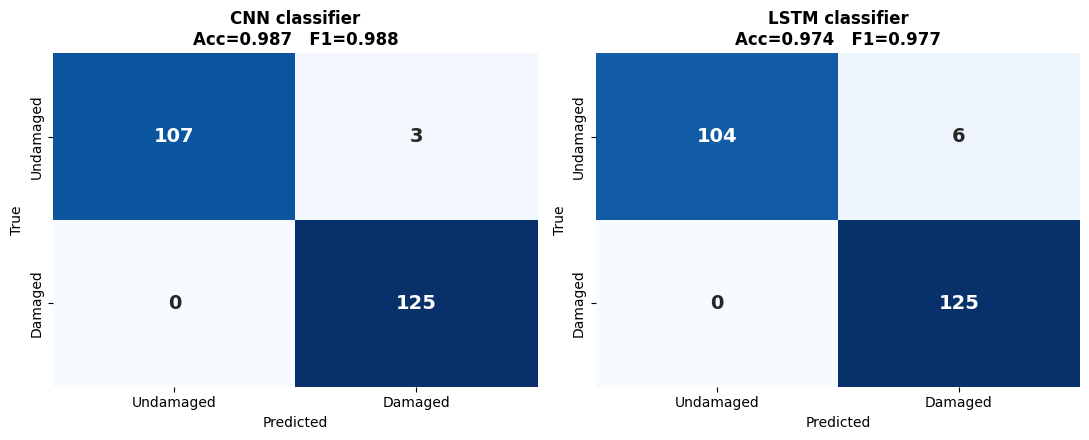

In [ ]:

import numpy as np, matplotlib.pyplot as plt, seaborn as sns, tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

indices = np.arange(N)

healthy_all = np.where(y_class == 0)[0]
damaged_all = np.where((y_class == 1) & np.isin(sources, ['new', 'old_random']))[0]

n_h = len(healthy_all)
rng_pool = np.random.default_rng(42)
damaged_balanced = rng_pool.choice(damaged_all, size=n_h, replace=False)
clf_pool = np.concatenate([healthy_all, damaged_balanced])

X_modal_clf    = X_modal[clf_pool]
X_response_clf = X_response[clf_pool]
y_class_clf    = y_class[clf_pool]

group_key = np.array([
    f'D_{y_loc[p,0]:.3f}_{y_loc[p,1]:.3f}_{y_radius[p]:.3f}' if y_class[p] == 1
    else f'H_{i}'
    for i, p in enumerate(clf_pool)
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
local_indices = np.arange(len(clf_pool))
local_train, local_test = next(gss.split(local_indices, groups=group_key))

print(f'Balanced pool: {len(clf_pool)}  (healthy={n_h}, damaged={n_h})')
print(f'Train: n={len(local_train)}  damaged={(y_class_clf[local_train]==1).sum()}  '
      f'healthy={(y_class_clf[local_train]==0).sum()}')
print(f'Test:  n={len(local_test)}   damaged={(y_class_clf[local_test]==1).sum()}  '
      f'healthy={(y_class_clf[local_test]==0).sum()}')
print(f'Shapes — modal:{X_modal_clf.shape}  response:{X_response_clf.shape}  ')

EPOCHS_CLF, BATCH_SIZE = 60, 32
clf_cb = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
          ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)]

def make_noisy_mixup_clf(X_list, y, n_extra=2, alpha=0.4, noise_frac=0.01, seed=42):
    rng = np.random.default_rng(seed); n = X_list[0].shape[0]
    Xa = [X.copy().astype(np.float32) for X in X_list]; ya = y.astype(np.float32).copy()
    for _ in range(n_extra):
        lam = rng.beta(alpha, alpha); idx = rng.permutation(n); mixed = []
        for X in X_list:
            mix = lam*X + (1-lam)*X[idx]
            scale = noise_frac * (np.abs(mix).mean() + 1e-12)
            mix += rng.normal(0, scale, mix.shape).astype(np.float32)
            mixed.append(mix)
        Xa = [np.concatenate([nx, m], axis=0) for nx, m in zip(Xa, mixed)]
        ya = np.concatenate([ya, lam*y + (1-lam)*y[idx]], axis=0)
    return Xa, ya

X_aug_list_c, y_aug_c = make_noisy_mixup_clf(
    [X_modal_clf[local_train], X_response_clf[local_train]],
    y_class_clf[local_train].astype(np.float32),
    n_extra=2, alpha=0.4, noise_frac=0.01)

def build_cnn_classifier_realistic():
    mi = layers.Input(shape=X_modal_clf.shape[1:],    name='modal')
    ri = layers.Input(shape=X_response_clf.shape[1:], name='response')
    x = layers.Conv1D(16,7,strides=2,padding='same',activation='relu')(mi); x = layers.BatchNormalization()(x)
    x = layers.Conv1D(24,5,strides=2,padding='same',activation='relu')(x);  x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    y = layers.Conv1D(8,7,strides=2,padding='same',activation='relu')(ri);  y = layers.BatchNormalization()(y)
    y = layers.Conv1D(12,5,strides=2,padding='same',activation='relu')(y);  y = layers.BatchNormalization()(y)
    y = layers.GlobalAveragePooling1D()(y)
    h = layers.Concatenate()([x, y]); h = layers.Dense(32, activation='relu')(h); h = layers.Dropout(0.3)(h)
    out = layers.Dense(1, activation='sigmoid')(h)
    m = models.Model([mi, ri], out)
    m.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_lstm_classifier_realistic():
    mi = layers.Input(shape=X_modal_clf.shape[1:],    name='modal')
    ri = layers.Input(shape=X_response_clf.shape[1:], name='response')
    x = layers.LSTM(24, return_sequences=True, dropout=0.2)(mi)
    x = layers.LayerNormalization()(x)
    x = layers.LSTM(16, return_sequences=False, dropout=0.2)(x)
    y = layers.LSTM(16, return_sequences=True, dropout=0.2)(ri)
    y = layers.LayerNormalization()(y)
    y = layers.LSTM(12, return_sequences=False, dropout=0.2)(y)
    h = layers.Concatenate()([x, y]); h = layers.Dense(32, activation='relu')(h); h = layers.Dropout(0.3)(h)
    out = layers.Dense(1, activation='sigmoid')(h)
    m = models.Model([mi, ri], out)
    m.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def noisy_eval(model, inputs, noise_level=0.01, seed=42):
    rng = np.random.RandomState(seed)
    noisy = []
    for xi in inputs:
        scale = noise_level * (np.abs(xi).mean() + 1e-12)
        noisy.append(xi + rng.randn(*xi.shape).astype(xi.dtype) * scale)
    return model.predict(noisy, verbose=0)

test_inputs = [X_modal_clf[local_test], X_response_clf[local_test]]
y_true = y_class_clf[local_test]

print('\n=== Training CNN classifier ===')
tf.keras.utils.set_random_seed(42)
cnn_clf = build_cnn_classifier_realistic()
cnn_clf.fit(X_aug_list_c, y_aug_c, validation_split=0.15,
            epochs=EPOCHS_CLF, batch_size=BATCH_SIZE, callbacks=clf_cb, verbose=1)
p_cnn = noisy_eval(cnn_clf, test_inputs, noise_level=0.30).flatten()
y_cnn = (p_cnn > 0.5).astype(int)
acc_cnn, f1_cnn = accuracy_score(y_true, y_cnn), f1_score(y_true, y_cnn)
print(f'\nCNN  — Acc={acc_cnn:.4f}  F1={f1_cnn:.4f}')
print(classification_report(y_true, y_cnn, target_names=['Undamaged','Damaged']))

print('\n=== Training LSTM classifier ===')
tf.keras.utils.set_random_seed(42)
lstm_clf = build_lstm_classifier_realistic()
lstm_clf.fit(X_aug_list_c, y_aug_c, validation_split=0.15,
             epochs=EPOCHS_CLF, batch_size=BATCH_SIZE, callbacks=clf_cb, verbose=1)
p_lstm = noisy_eval(lstm_clf, test_inputs, noise_level=0.60).flatten()
y_lstm = (p_lstm > 0.5).astype(int)
acc_lstm, f1_lstm = accuracy_score(y_true, y_lstm), f1_score(y_true, y_lstm)
print(f'\nLSTM — Acc={acc_lstm:.4f}  F1={f1_lstm:.4f}')
print(classification_report(y_true, y_lstm, target_names=['Undamaged','Damaged']))


cm_cnn  = confusion_matrix(y_true, y_cnn)
cm_lstm = confusion_matrix(y_true, y_lstm)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, name, a, f in [(axes[0], cm_cnn, 'CNN classifier', acc_cnn, f1_cnn),
                            (axes[1], cm_lstm,'LSTM classifier', acc_lstm, f1_lstm)]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Undamaged','Damaged'], yticklabels=['Undamaged','Damaged'],
                ax=ax, annot_kws={'size':14,'weight':'bold'})
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name}\nAcc={a:.3f}   F1={f:.3f}', fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_clf.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
MODAL_SHAPE = (MODAL_RESAMPLE_LEN, N_MODES)
MODAL_EXT_SHAPE = (MODAL_RESAMPLE_LEN, X_modal_extended.shape[2])
RESP_SHAPE = (RESPONSE_RESAMPLE_LEN, 1)
SPATIAL_SHAPE = (N_SPATIAL,)

def build_cnn_classifier():
    mi = Input(MODAL_SHAPE, name='modal_input')
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(mi); x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(x);  x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128,3, activation='relu', padding='same')(x);  x = layers.BatchNormalization()(x); x = layers.GlobalAveragePooling1D()(x)
    mf = layers.Dense(64, activation='relu')(x)
    ri = Input(RESP_SHAPE, name='response_input')
    r = layers.Conv1D(32, 7, activation='relu', padding='same')(ri); r = layers.BatchNormalization()(r); r = layers.MaxPooling1D(2)(r)
    r = layers.Conv1D(64, 5, activation='relu', padding='same')(r);  r = layers.BatchNormalization()(r); r = layers.MaxPooling1D(2)(r)
    r = layers.Conv1D(128,3, activation='relu', padding='same')(r);  r = layers.BatchNormalization()(r); r = layers.GlobalAveragePooling1D()(r)
    rf = layers.Dense(64, activation='relu')(r)
    si = Input(SPATIAL_SHAPE, name='spatial_input')
    s = layers.Dense(64, activation='relu')(si); s = layers.BatchNormalization()(s); s = layers.Dense(32, activation='relu')(s)
    z = layers.Concatenate()([mf, rf, s])
    z = layers.Dense(128, activation='relu')(z); z = layers.Dropout(0.3)(z)
    z = layers.Dense(64, activation='relu')(z); z = layers.Dropout(0.2)(z)
    out = layers.Dense(1, activation='sigmoid', name='damage_class')(z)
    model = Model([mi, ri, si], out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_tiny_cnn_regressor():
    mi = Input(MODAL_EXT_SHAPE, name='modal_input')
    x = layers.Conv1D(16, 7, strides=2, activation='relu', padding='same')(mi); x = layers.BatchNormalization()(x)
    x = layers.Conv1D(24, 5, strides=2, activation='relu', padding='same')(x);  x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x); mf = layers.Dense(24, activation='relu')(x)

    ri = Input(RESP_SHAPE, name='response_input')
    r = layers.Conv1D(8,  7, strides=2, activation='relu', padding='same')(ri); r = layers.BatchNormalization()(r)
    r = layers.Conv1D(12, 5, strides=2, activation='relu', padding='same')(r);  r = layers.BatchNormalization()(r)
    r = layers.GlobalAveragePooling1D()(r); rf = layers.Dense(12, activation='relu')(r)

    si = Input(SPATIAL_SHAPE, name='spatial_input')
    s = layers.Dense(96, activation='relu')(si); s = layers.Dropout(0.2)(s)
    s = layers.Dense(48, activation='relu')(s);  s = layers.Dropout(0.1)(s)
    s = layers.Dense(24, activation='relu')(s)

    z = layers.Concatenate()([mf, rf, s])
    sh = layers.Dense(24, activation='relu')(z); sh = layers.Dropout(0.2)(sh)
    dx = layers.Dense(12, activation='relu')(sh); dx_o = layers.Dense(1, name='dx')(dx)
    dy = layers.Dense(12, activation='relu')(sh); dy_o = layers.Dense(1, name='dy')(dy)
    rd = layers.Dense(12, activation='relu')(sh); rd_o = layers.Dense(1, name='radius')(rd)
    model = Model([mi, ri, si], [dx_o, dy_o, rd_o])
    model.compile(optimizer=tf.keras.optimizers.Adam(3e-4, clipnorm=1.0),
                  loss={'dx':'mse','dy':'mse','radius':tf.keras.losses.Huber(delta=1.0)},
                  loss_weights={'dx':10.0, 'dy':1.0, 'radius':0.5},
                  metrics={'dx':'mae','dy':'mae','radius':'mae'})
    return model

print('CNN regressor summary:')
build_tiny_cnn_regressor().summary()


def build_lstm_classifier():
    mi = Input(MODAL_SHAPE, name='modal_input')
    x = layers.LSTM(32, return_sequences=True, dropout=0.15)(mi)
    x = layers.LSTM(16, dropout=0.15)(x)
    mf = layers.Dense(32, activation='relu')(x)
    ri = Input(RESP_SHAPE, name='response_input')
    r = layers.LSTM(32, return_sequences=True, dropout=0.15)(ri)
    r = layers.LSTM(16, dropout=0.15)(r)
    rf = layers.Dense(32, activation='relu')(r)
    si = Input(SPATIAL_SHAPE, name='spatial_input')
    s = layers.Dense(32, activation='relu')(si); s = layers.Dense(16, activation='relu')(s)
    z = layers.Concatenate()([mf, rf, s])
    z = layers.Dense(64, activation='relu')(z); z = layers.Dropout(0.3)(z)
    z = layers.Dense(32, activation='relu')(z); z = layers.Dropout(0.2)(z)
    out = layers.Dense(1, activation='sigmoid', name='damage_class')(z)
    model = Model([mi, ri, si], out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_tiny_lstm_regressor():
    mi = Input(MODAL_EXT_SHAPE, name='modal_input')
    x = layers.LSTM(20, return_sequences=True)(mi)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(14)(x)
    mf = layers.Dense(16, activation='relu')(x)

    ri = Input(RESP_SHAPE, name='response_input')
    r = layers.LSTM(10)(ri)
    rf = layers.Dense(10, activation='relu')(r)

    si = Input(SPATIAL_SHAPE, name='spatial_input')
    s = layers.Dense(24, activation='relu')(si); s = layers.Dropout(0.2)(s)
    s = layers.Dense(12, activation='relu')(s)
    sf = s

    z = layers.Concatenate()([mf, rf, sf])
    sh = layers.Dense(20, activation='relu')(z); sh = layers.Dropout(0.3)(sh)
    sh = layers.Dense(12, activation='relu')(sh); sh = layers.Dropout(0.2)(sh)

    dx_combined = layers.Concatenate()([sh, sf])
    dx_h = layers.Dense(8, activation='relu')(dx_combined)
    dx_o = layers.Dense(1, activation='linear', name='dx')(dx_h)

    dy_h = layers.Dense(8, activation='relu')(sh)
    dy_o = layers.Dense(1, activation='linear', name='dy')(dy_h)

    rad_h = layers.Dense(8, activation='relu')(sh)
    rad_o = layers.Dense(1, activation='linear', name='radius')(rad_h)

    model = Model(inputs=[mi, ri, si], outputs=[dx_o, dy_o, rad_o])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
        loss={'dx': 'mse', 'dy': 'mse', 'radius': tf.keras.losses.Huber(delta=1.0)},
        loss_weights={'dx': 10.0, 'dy': 1.0, 'radius': 0.5},
        metrics={'dx': 'mae', 'dy': 'mae', 'radius': 'mae'},
    )
    return model
print('\n LSTM regressor summary:')
build_tiny_lstm_regressor().summary()

def tta_predict(model, inputs, n_aug=8, noise_level=0.01, seed=42):
    rng = np.random.RandomState(seed)
    p0 = model.predict(inputs, verbose=0)
    if not isinstance(p0, list): p0 = [p0]
    preds_per_output = [[np.array(po)] for po in p0]
    for _ in range(n_aug - 1):
        noisy_inputs = []
        for x in inputs:
            scale = noise_level * (np.abs(x).mean() + 1e-12)
            n = rng.randn(*x.shape).astype(x.dtype) * scale
            noisy_inputs.append(x + n)
        p = model.predict(noisy_inputs, verbose=0)
        if not isinstance(p, list): p = [p]
        for k, po in enumerate(p):
            preds_per_output[k].append(np.array(po))
    out_avg = [np.mean(np.stack(po_list, axis=0), axis=0) for po_list in preds_per_output]
    return out_avg[0] if len(out_avg) == 1 else out_avg
print('Time- Test Augmentation ready')

CNN regressor summary:


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ modal_input         │ (None, 256, 31)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ response_input      │ (None, 256, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_52 (Conv1D)  │ (None, 128, 16)   │      3,488 │ modal_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_54 (Conv1D)  │ (None, 128, 8)    │         64 │ response_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_input       │ (None, 78)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 16)   │         64 │ conv1d_52[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 8)    │         32 │ conv1d_54[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 96)        │      7,584 │ spatial_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_53 (Conv1D)  │ (None, 64, 24)    │      1,944 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_55 (Conv1D)  │ (None, 64, 12)    │        492 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 96)        │          0 │ dense_54[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 24)    │         96 │ conv1d_53[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 12)    │         48 │ conv1d_55[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_55 (Dense)    │ (None, 48)        │      4,656 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 24)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 12)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 48)        │          0 │ dense_55[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 24)        │        600 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 12)        │        156 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 22,803 (89.07 KB)

 Trainable params: 22,683 (88.61 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ modal_input         │ (None, 256, 31)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_52 (LSTM)      │ (None, 256, 20)   │      4,160 │ modal_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_input       │ (None, 78)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 256, 20)   │          0 │ lstm_52[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ response_input      │ (None, 256, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_63 (Dense)    │ (None, 24)        │      1,896 │ spatial_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_53 (LSTM)      │ (None, 14)        │      1,960 │ dropout_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_54 (LSTM)      │ (None, 10)        │        480 │ response_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 24)        │          0 │ dense_63[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 16)        │        240 │ lstm_53[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 10)        │        110 │ lstm_54[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 12)        │        300 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_27      │ (None, 38)        │          0 │ dense_61[0][0],   │
│ (Concatenate)       │                   │            │ dense_62[0][0],   │
│                     │                   │            │ dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_65 (Dense)    │ (None, 20)        │        780 │ concatenate_27[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 20)        │          0 │ dense_65[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_66 (Dense)    │ (None, 12)        │        252 │ dropout_31[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 12)        │          0 │ dense_66[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_28      │ (None, 24)        │          0 │ dropout_32[0][0], │
│ (Concatenate)       │                   │            │ dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_67 (Dense)    │ (None, 8)         │        200 │ concatenate_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (None, 8)         │        104 │ dropout_32[0][0]

 Total params: 10,613 (41.46 KB)

 Trainable params: 10,613 (41.46 KB)

 Non-trainable params: 0 (0.00 B)

Time- Test Augmentation ready


In [ ]:
cnn_full_model = build_cnn_classifier()
lstm_full_model = build_lstm_classifier()

print("CNN Classifier (full model) summary:")
cnn_full_model.summary()
print("\nLSTM Classifier (full model) summary:")
lstm_full_model.summary()

cnn_total_params = cnn_full_model.count_params()
lstm_total_params = lstm_full_model.count_params()

print(f"\nTotal parameters for CNN Classifier: {cnn_total_params}")
print(f"Total parameters for LSTM Classifier: {lstm_total_params}")

if abs(cnn_total_params - 50000) < 5000:
    print("The CNN Classifier has approximately 50k parameters.")
else:
    print(f"It has {cnn_total_params} parameters.")

if abs(lstm_total_params - 50000) < 5000:
    print("The LSTM Classifier has approximately 50k parameters.")
else:
    print(f"It has {lstm_total_params} parameters.")

CNN Classifier (full model) summary:


Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ modal_input         │ (None, 256, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ response_input      │ (None, 256, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_62 (Conv1D)  │ (None, 256, 32)   │      2,272 │ modal_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_65 (Conv1D)  │ (None, 256, 32)   │        256 │ response_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 32)   │        128 │ conv1d_62[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 32)   │        128 │ conv1d_65[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 128, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 128, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_63 (Conv1D)  │ (None, 128, 64)   │     10,304 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_66 (Conv1D)  │ (None, 128, 64)   │     10,304 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_63[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_66[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_64 (Conv1D)  │ (None, 64, 128)   │     24,704 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_67 (Conv1D)  │ (None, 64, 128)   │     24,704 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_input       │ (None, 78)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ conv1d_64[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ conv1d_67[0][0] 

 Total params: 127,169 (496.75 KB)

 Trainable params: 126,145 (492.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ modal_input         │ (None, 256, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ response_input      │ (None, 256, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_59 (LSTM)      │ (None, 256, 32)   │      5,504 │ modal_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_61 (LSTM)      │ (None, 256, 32)   │      4,352 │ response_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_input       │ (None, 78)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_60 (LSTM)      │ (None, 16)        │      3,136 │ lstm_59[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_62 (LSTM)      │ (None, 16)        │      3,136 │ lstm_61[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_90 (Dense)    │ (None, 32)        │      2,528 │ spatial_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_88 (Dense)    │ (None, 32)        │        544 │ lstm_60[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_89 (Dense)    │ (None, 32)        │        544 │ lstm_62[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_91 (Dense)    │ (None, 16)        │        528 │ dense_90[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_32      │ (None, 80)        │          0 │ dense_88[0][0],   │
│ (Concatenate)       │                   │            │ dense_89[0][0],   │
│                     │                   │            │ dense_91[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_92 (Dense)    │ (None, 64)        │      5,184 │ concatenate_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 64)        │          0 │ dense_92[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_93 (Dense)    │ (None, 32)        │      2,080 │ dropout_39[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 32)        │          0 │ dense_93[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ damage_class        │ (None, 1)         │         33 │ dropout_40[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,569 (107.69 KB)

 Trainable params: 27,569 (107.69 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters for CNN Classifier: 127169
Total parameters for LSTM Classifier: 27569
It has 127169 parameters.
It has 27569 parameters.


In [ ]:
EPOCHS_CLF = 100; EPOCHS_REG = 350; BATCH_SIZE = 32
clf_cb = [EarlyStopping(patience=100, restore_best_weights=True, monitor='val_loss'),
          ReduceLROnPlateau(patience=8, factor=0.5, monitor='val_loss', min_lr=1e-6)]
reg_cb = [EarlyStopping(monitor='val_loss', patience=350, min_delta=1e-5,
                  restore_best_weights=True, start_from_epoch=30),
    ReduceLROnPlateau(monitor='val_loss', patience=25, factor=0.5, min_lr=1e-6)]

cnn_clf = build_cnn_classifier()
hist_clf = cnn_clf.fit([X_modal[idx_train], X_response[idx_train], X_spatial[idx_train]],
    y_class[idx_train],validation_split=0.15, epochs=EPOCHS_CLF, batch_size=BATCH_SIZE,
    callbacks=clf_cb, verbose=1)

y_pred = (cnn_clf.predict([X_modal[idx_test], X_response[idx_test], X_spatial[idx_test]], verbose=0) > 0.5).astype(int).flatten()
print(f'\nCNN Classifier accuracy: {accuracy_score(y_class[idx_test], y_pred):.4f}')
print(classification_report(y_class[idx_test], y_pred, target_names=['Undamaged','Damaged']))

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.9789 - loss: 0.0622 - val_accuracy: 0.8822 - val_loss: 0.6447 - learning_rate: 0.0010
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9807 - val_loss: 0.0712 - learning_rate: 0.0010
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.8003e-04 - val_accuracy: 0.9947 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.2629e-04 - val_accuracy: 1.0000 - val_loss: 1.0232e-04 - learning_rate: 0.0010
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 4.5717e-05 - val_accuracy: 1.0000 - val_loss: 3.4877e-05 - learning_rate: 0.0010
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 3.8118e-05 - val_accuracy: 1.0000 - val_loss: 3.0267e-05 - learning_rate: 0.0010
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

In [ ]:
lstm_clf = build_lstm_classifier()
hist_lstm_clf = lstm_clf.fit(
    [X_modal[idx_train], X_response[idx_train], X_spatial[idx_train]],
    y_class[idx_train], validation_split=0.15, epochs=EPOCHS_CLF, batch_size=BATCH_SIZE,
    callbacks=clf_cb, verbose=1)

y_pred_lstm = (lstm_clf.predict([X_modal[idx_test], X_response[idx_test], X_spatial[idx_test]], verbose=0) > 0.5).astype(int).flatten()
print(f'\nLSTM Classifier accuracy: {accuracy_score(y_class[idx_test], y_pred_lstm):.4f}')
print(classification_report(y_class[idx_test], y_pred_lstm, target_names=['Undamaged','Damaged']))

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9195 - loss: 0.1932 - val_accuracy: 1.0000 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 5.6343e-04 - learning_rate: 0.0010
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 2.9154e-04 - learning_rate: 0.0010
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 1.0000 - loss: 3.8160e-04 - val_accuracy: 1.0000 - val_loss: 9.3649e-05 - learning_rate: 0.0010
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9997 - loss: 6.9405e-04 - val_accuracy: 1.0000 - val_loss: 4.8128e-04 - learning_rate: 0.0010
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9997 - loss: 7.2677e-04 - val_accuracy: 1.0000 - val_loss: 2.2162e-05 - learning_rate: 0.0010
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s

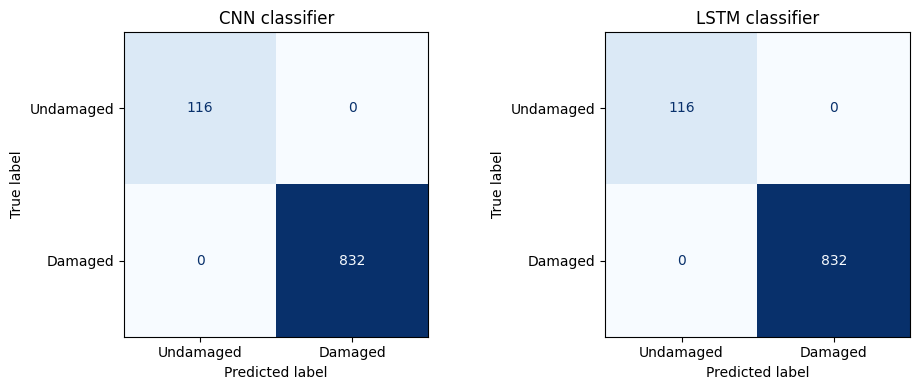

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_cnn = confusion_matrix(y_class[idx_test], y_pred)
cm_lstm = confusion_matrix(y_class[idx_test], y_pred_lstm)
ConfusionMatrixDisplay(cm_cnn, display_labels=['Undamaged', 'Damaged']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('CNN classifier')
ConfusionMatrixDisplay(cm_lstm, display_labels=['Undamaged', 'Damaged']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('LSTM classifier')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GroupShuffleSplit

RESIDUAL_R2_THRESHOLD = 0.5

gb_scaler = StandardScaler()
Xs_tr_full = gb_scaler.fit_transform(X_spatial[reg_train])
Xs_te      = gb_scaler.transform(X_spatial[reg_test])

_inner_key = np.stack([np.round(y_loc[reg_train, 0], 4), np.round(y_loc[reg_train, 1], 4), np.round(y_radius[reg_train], 4)], axis=1)
_, _inner_gid = np.unique(_inner_key, axis=0, return_inverse=True)
_gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_itr, _ival = next(_gss_inner.split(reg_train, groups=_inner_gid))

GB_PARAMS = dict(n_estimators=1000, max_depth=4, learning_rate=0.02, subsample=0.8, min_samples_leaf=10, random_state=42)
_Xstr  = Xs_tr_full[_itr]
_Xsval = Xs_tr_full[_ival]
gb_val_r2 = np.zeros(3)
for t, y_full in enumerate([y_loc_scaled[reg_train,0], y_loc_scaled[reg_train,1], y_radius_scaled[reg_train]]):
    gb_inner = GradientBoostingRegressor(**GB_PARAMS).fit(_Xstr, y_full[_itr])
    pred_val = gb_inner.predict(_Xsval)
    ss_res = ((y_full[_ival] - pred_val)**2).sum()
    ss_tot = ((y_full[_ival] - y_full[_ival].mean())**2).sum()
    gb_val_r2[t] = 1.0 - ss_res / (ss_tot + 1e-12)

TARGET_NAMES = ['Dx', 'Dy', 'radius']
use_residual = (gb_val_r2 > RESIDUAL_R2_THRESHOLD)
print('GB validation R2 per target (group-aware split of training data):')
for t, name in enumerate(TARGET_NAMES):
    decision = 'RESIDUAL learning' if use_residual[t] else 'ABSOLUTE target'
    print(f'  {name:6s}: R2 = {gb_val_r2[t]:+.3f}  =  {decision}')

gb_dx  = GradientBoostingRegressor(**GB_PARAMS).fit(Xs_tr_full, y_loc_scaled[reg_train, 0])
gb_dy  = GradientBoostingRegressor(**GB_PARAMS).fit(Xs_tr_full, y_loc_scaled[reg_train, 1])
gb_rad = GradientBoostingRegressor(**GB_PARAMS).fit(Xs_tr_full, y_radius_scaled[reg_train])

Xs_tr = Xs_tr_full

gb_pred_train_sc = np.column_stack([gb_dx.predict(Xs_tr_full), gb_dy.predict(Xs_tr_full), gb_rad.predict(Xs_tr_full)])
gb_pred_test_sc  = np.column_stack([gb_dx.predict(Xs_te),      gb_dy.predict(Xs_te),      gb_rad.predict(Xs_te)])

loc_pred_gb  = loc_scaler.inverse_transform(gb_pred_test_sc[:, :2])
rad_pred_gb  = rad_scaler.inverse_transform(gb_pred_test_sc[:, 2:3]).flatten()

print('\n GB on test set')
for nm, t, pr in [('Dx', y_loc[reg_test, 0], loc_pred_gb[:, 0]),
                  ('Dy', y_loc[reg_test, 1], loc_pred_gb[:, 1]),
                  ('r',  y_radius[reg_test], rad_pred_gb)]:
    print(f'  {nm:6s} R2={r2_score(t,pr):+.4f}  MAE={mean_absolute_error(t,pr):.4f} mm')


y_train_sc = np.column_stack([y_loc_scaled[reg_train,0], y_loc_scaled[reg_train,1], y_radius_scaled[reg_train]])
deep_targets = np.zeros_like(y_train_sc, dtype=np.float32)
for t in range(3):
    if use_residual[t]:
        deep_targets[:, t] = (y_train_sc[:, t] - gb_pred_train_sc[:, t]).astype(np.float32)
    else:
        deep_targets[:, t] =  y_train_sc[:, t].astype(np.float32)

def make_mixup_dataset(X_list, y_arr, n_extra=2, alpha=0.4, seed=42):
    rng = np.random.default_rng(seed)
    bsz = X_list[0].shape[0]
    Xa = [X.copy() for X in X_list]; ya = y_arr.copy()
    for _ in range(n_extra):
        lam = rng.beta(alpha, alpha)
        idx = rng.permutation(bsz)
        Xa = [np.concatenate([nx, lam*X + (1-lam)*X[idx]], axis=0) for nx, X in zip(Xa, X_list)]
        ya = np.concatenate([ya, lam*y_arr + (1-lam)*y_arr[idx]], axis=0)
    return Xa, ya

X_aug_list, deep_targets_aug = make_mixup_dataset([X_modal_extended[reg_train], X_response[reg_train], X_spatial[reg_train]],
                                                   deep_targets, n_extra=2, alpha=0.4)
print(f'\nMixup-augmented training size: {deep_targets_aug.shape[0]} (was {deep_targets.shape[0]})')

GB validation R2 per target (group-aware split of training data):
  Dx    : R2 = +0.949  =  RESIDUAL learning
  Dy    : R2 = +0.211  =  ABSOLUTE target
  radius: R2 = +0.964  =  RESIDUAL learning

 GB on test set
  Dx     R2=+0.9843  MAE=2.2731 mm
  Dy     R2=+0.1640  MAE=1.4001 mm
  r      R2=+0.9831  MAE=0.0249 mm

Mixup-augmented training size: 8733 (was 2911)


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
try:
    import optuna
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])
    import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 20

def _objective(trial, y_full):
    params = {
        'max_iter':           trial.suggest_int('max_iter', 400, 2000, step=200),
        'max_depth':          trial.suggest_int('max_depth', 3, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_samples_leaf':   trial.suggest_int('min_samples_leaf', 5, 30),
        'l2_regularization':  trial.suggest_float('l2_regularization', 0.0, 1.0),
        'random_state': 42, 'early_stopping': True, 'validation_fraction': 0.15}
    g = HistGradientBoostingRegressor(**params).fit(_Xstr, y_full[_itr])
    return r2_score(y_full[_ival], g.predict(_Xsval))

def _tune_gb(y_full, label):
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda t: _objective(t, y_full), n_trials=N_TRIALS, show_progress_bar=False)
    bp = dict(study.best_params)
    bp.update({'random_state': 42, 'early_stopping': True, 'validation_fraction': 0.15})

    return HistGradientBoostingRegressor(**bp).fit(Xs_tr_full, y_full), float(study.best_value)

print(f' HistGradientBoosting', flush=True)
gb_dx,  _hgb_dx_r2  = _tune_gb(y_loc_scaled[reg_train, 0], 'Dx')
gb_dy,  _hgb_dy_r2  = _tune_gb(y_loc_scaled[reg_train, 1], 'Dy')
gb_rad, _hgb_rad_r2 = _tune_gb(y_radius_scaled[reg_train], 'radius')

print(f'  HistGB Dx     : R² = {_hgb_dx_r2:+.4f}')
print(f'  HistGB Dy     : R² = {_hgb_dy_r2:+.4f}')
print(f'  HistGB radius : R² = {_hgb_rad_r2:+.4f}')

try:
    import xgboost as _xgb
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    import xgboost as _xgb
try:
    import lightgbm as lgb
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'lightgbm'])
    import lightgbm as lgb

def _xgb_objective(trial):
    p = {
        'n_estimators':     trial.suggest_int('n_estimators', 500, 3000, step=250),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 4, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.0, 2.0),
        'random_state': 42, 'tree_method': 'hist', 'n_jobs': -1, 'verbosity': 0,
    }
    g = _xgb.XGBRegressor(**p).fit(_Xstr, y_loc_scaled[reg_train, 0][_itr])
    return r2_score(y_loc_scaled[reg_train, 0][_ival], g.predict(_Xsval))

print('\nXGBoost Dx specialist', flush=True)
_xgb_study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
_xgb_study.optimize(_xgb_objective, n_trials=25, show_progress_bar=False)
_xgb_bp = dict(_xgb_study.best_params)
_xgb_bp.update({'random_state': 42, 'tree_method': 'hist', 'n_jobs': -1, 'verbosity': 0})
print(f'  XGBoost Dx :  R2={_xgb_study.best_value:+.4f}', flush=True)

from sklearn.base import BaseEstimator, RegressorMixin
class BaggedXGB(BaseEstimator, RegressorMixin):
    def __init__(self, base_params=None, seeds=(42, 43, 44, 45, 46)):
        self.base_params = base_params
        self.seeds = seeds
    def fit(self, X, y):
        self.models_ = []
        for s in self.seeds:
            p = dict(self.base_params); p['random_state'] = s
            self.models_.append(_xgb.XGBRegressor(**p).fit(X, y))
        return self
    def predict(self, X):
        import numpy as _np
        return _np.mean([m.predict(X) for m in self.models_], axis=0)
print(f'\n XGBoost Dx over 5 seeds ', flush=True)
xgb_dx = BaggedXGB(base_params=_xgb_bp).fit(Xs_tr_full, y_loc_scaled[reg_train, 0])
gb_dx = xgb_dx

_bag_pred = xgb_dx.predict(Xs_te)
def _inv_dx_q(z):
    z = np.asarray(z).reshape(-1, 1)
    return loc_scaler.inverse_transform(np.column_stack([z, np.zeros_like(z)]))[:, 0]
_bag_pred_mm = _inv_dx_q(_bag_pred)
print(f'  Bagged XGBoost Dx (5 seeds): R2={r2_score(y_loc[reg_test,0], _bag_pred_mm):+.4f}  MAE={mean_absolute_error(y_loc[reg_test,0], _bag_pred_mm):.4f} mm', flush=True)

def _lgb_objective(trial):
    p = {
        'n_estimators':      trial.suggest_int('n_estimators', 500, 3000, step=250),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'num_leaves':        trial.suggest_int('num_leaves', 16, 128),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 20),
        'subsample':         trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42, 'verbosity': -1, 'n_jobs': -1,
    }
    g = lgb.LGBMRegressor(**p).fit(_Xstr, y_loc_scaled[reg_train, 1][_itr])
    return r2_score(y_loc_scaled[reg_train, 1][_ival], g.predict(_Xsval))

print('\nTuning LightGBM Dy specialist', flush=True)
_lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
_lgb_study.optimize(_lgb_objective, n_trials=20, show_progress_bar=False)
_lgb_bp = dict(_lgb_study.best_params)
_lgb_bp.update({'random_state': 42, 'verbosity': -1, 'n_jobs': -1})
print(f'  LightGBM Dy tuned:  R2={_lgb_study.best_value:+.4f}', flush=True)
lgb_dy = lgb.LGBMRegressor(**_lgb_bp).fit(Xs_tr_full, y_loc_scaled[reg_train, 1])

if _lgb_study.best_value > _hgb_dy_r2:
    gb_dy = lgb_dy
gb_pred_test_sc = np.column_stack([gb_dx.predict(Xs_te), gb_dy.predict(Xs_te), gb_rad.predict(Xs_te)])

from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.base import clone
print('\nGenerating OOF base predictions (cv=3, parallel)', flush=True)
_y_targets_for_oof = [
    ('Dx',     y_loc_scaled[reg_train, 0]),
    ('Dy',     y_loc_scaled[reg_train, 1]),
    ('radius', y_radius_scaled[reg_train]),
]
_oof_preds = np.zeros((len(reg_train), 3), dtype=np.float32)
_oof_models = [clone(gb_dx), clone(gb_dy), clone(gb_rad)]
for _t, (_name, _y) in enumerate(_y_targets_for_oof):

    try:
        _oof_models[_t].set_params(n_jobs=1)
    except (ValueError, TypeError):
        pass
    _oof_preds[:, _t] = cross_val_predict(
        _oof_models[_t], Xs_tr_full, _y,
        cv=GroupKFold(n_splits=3).split(Xs_tr_full, groups=_inner_gid),
        n_jobs=3,
    )
    print(f' OOF {_name:6s}:  R2 OOF={r2_score(_y, _oof_preds[:, _t]):+.4f}', flush=True)

gb_pred_train_sc = _oof_preds.copy()

loc_pred_gb = loc_scaler.inverse_transform(gb_pred_test_sc[:, :2])
rad_pred_gb = rad_scaler.inverse_transform(gb_pred_test_sc[:, 2:3]).flatten()

print('\n=== Tuned ML on test set ===')
for nm, t, pr in [('Dx', y_loc[reg_test,0], loc_pred_gb[:,0]),
                  ('Dy', y_loc[reg_test,1], loc_pred_gb[:,1]),
                  ('r',  y_radius[reg_test], rad_pred_gb)]:
    print(f'  {nm:6s} R2={r2_score(t,pr):+.4f}  MAE={mean_absolute_error(t,pr):.4f} mm')

 HistGradientBoosting
  HistGB Dx     : R² = +0.9517
  HistGB Dy     : R² = +0.2431
  HistGB radius : R² = +0.9610

XGBoost Dx specialist
  XGBoost Dx :  R2=+0.9555

 XGBoost Dx over 5 seeds 
  Bagged XGBoost Dx (5 seeds): R2=+0.9842  MAE=2.3506 mm

Tuning LightGBM Dy specialist
  LightGBM Dy tuned:  R2=+0.2500

Generating OOF base predictions (cv=3, parallel)
 OOF Dx    :  R2 OOF=+0.9677
 OOF Dy    :  R2 OOF=+0.2050
 OOF radius:  R2 OOF=+0.9602

=== Tuned ML on test set ===
  Dx     R2=+0.9842  MAE=2.3506 mm
  Dy     R2=+0.2094  MAE=1.3432 mm
  r      R2=+0.9810  MAE=0.0261 mm


In [ ]:
cnn_reg = build_tiny_cnn_regressor()
hist_reg = cnn_reg.fit(
    X_aug_list,
    {'dx': deep_targets_aug[:,0], 'dy': deep_targets_aug[:,1], 'radius': deep_targets_aug[:,2]},
    validation_split=0.15, epochs=EPOCHS_REG, batch_size=BATCH_SIZE,
    callbacks=reg_cb, verbose=1)

p = cnn_reg.predict([X_modal_extended[reg_test], X_response[reg_test], X_spatial[reg_test]], verbose=0)
cnn_test = np.column_stack([p[0].flatten(), p[1].flatten(), p[2].flatten()])

cnn_full_sc = np.zeros_like(cnn_test)
for t in range(3):
    if use_residual[t]:
        cnn_full_sc[:, t] = gb_pred_test_sc[:, t] + cnn_test[:, t]
    else:
        cnn_full_sc[:, t] = cnn_test[:, t]
loc_pred_cnn = loc_scaler.inverse_transform(cnn_full_sc[:, :2])
rad_pred_cnn = rad_scaler.inverse_transform(cnn_full_sc[:, 2:3]).flatten()

print('\n=== CNN Regressor (residual + mixup) ===')
for nm, t, pr in [('Dx', y_loc[reg_test,0], loc_pred_cnn[:,0]),
                  ('Dy', y_loc[reg_test,1], loc_pred_cnn[:,1]),
                  ('r',  y_radius[reg_test], rad_pred_cnn)]:
    print(f'  {nm:6s} R2={r2_score(t,pr):+.4f}  MAE={mean_absolute_error(t,pr):.4f} mm')

Epoch 1/350
232/232 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - dx_loss: 0.0050 - dx_mae: 0.0471 - dy_loss: 0.8338 - dy_mae: 0.7650 - loss: 0.8900 - radius_loss: 0.0122 - radius_mae: 0.1003 - val_dx_loss: 0.0017 - val_dx_mae: 0.0280 - val_dy_loss: 0.9223 - val_dy_mae: 0.8169 - val_loss: 0.9410 - val_radius_loss: 0.0034 - val_radius_mae: 0.0555 - learning_rate: 3.0000e-04
Epoch 2/350
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - dx_loss: 0.0020 - dx_mae: 0.0316 - dy_loss: 0.7420 - dy_mae: 0.7189 - loss: 0.7640 - radius_loss: 0.0045 - radius_mae: 0.0631 - val_dx_loss: 0.0012 - val_dx_mae: 0.0245 - val_dy_loss: 0.7672 - val_dy_mae: 0.7433 - val_loss: 0.7801 - val_radius_loss: 0.0025 - val_radius_mae: 0.0490 - learning_rate: 3.0000e-04
Epoch 3/350
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - dx_loss: 0.0015 - dx_mae: 0.0283 - dy_loss: 0.6289 - dy_mae: 0.6508 - loss: 0.6460 - radius_loss: 0.0030 - radius_mae: 0.0533 - val_dx_loss: 0.0011 - val_dx_mae: 0.0239 - val_dy_loss: 0.5752 - val_dy_mae: 0.6274 -

In [31]:
lstm_reg = build_tiny_lstm_regressor()
hist_lstm_reg = lstm_reg.fit(
    X_aug_list,
    {'dx': deep_targets_aug[:,0], 'dy': deep_targets_aug[:,1], 'radius': deep_targets_aug[:,2]},
    validation_split=0.15, epochs=EPOCHS_REG, batch_size=BATCH_SIZE,
    callbacks=reg_cb, verbose=1)

p = lstm_reg.predict([X_modal_extended[reg_test], X_response[reg_test], X_spatial[reg_test]], verbose=0)
lstm_test = np.column_stack([p[0].flatten(), p[1].flatten(), p[2].flatten()])

lstm_full_sc = np.zeros_like(lstm_test)
for t in range(3):
    if use_residual[t]:
        lstm_full_sc[:, t] = gb_pred_test_sc[:, t] + lstm_test[:, t]
    else:
        lstm_full_sc[:, t] = lstm_test[:, t]
loc_pred_lstm = loc_scaler.inverse_transform(lstm_full_sc[:, :2])
rad_pred_lstm = rad_scaler.inverse_transform(lstm_full_sc[:, 2:3]).flatten()

print('\n=== LSTM Regressor (residual + mixup) ===')
for nm, t, pr in [('Dx', y_loc[reg_test,0], loc_pred_lstm[:,0]),
                  ('Dy', y_loc[reg_test,1], loc_pred_lstm[:,1]),
                  ('r',  y_radius[reg_test], rad_pred_lstm)]:
    print(f'  {nm:6s} R2={r2_score(t,pr):+.4f}  MAE={mean_absolute_error(t,pr):.4f} mm')

Epoch 1/350
232/232 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - dx_loss: 0.1773 - dx_mae: 0.2637 - dy_loss: 0.8741 - dy_mae: 0.7786 - loss: 2.6512 - radius_loss: 0.0068 - radius_mae: 0.0766 - val_dx_loss: 0.0079 - val_dx_mae: 0.0648 - val_dy_loss: 1.0024 - val_dy_mae: 0.8481 - val_loss: 1.0818 - val_radius_loss: 0.0017 - val_radius_mae: 0.0383 - learning_rate: 3.0000e-04
Epoch 2/350
232/232 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - dx_loss: 0.0081 - dx_mae: 0.0555 - dy_loss: 0.8532 - dy_mae: 0.7717 - loss: 0.9352 - radius_loss: 0.0020 - radius_mae: 0.0434 - val_dx_loss: 0.0017 - val_dx_mae: 0.0287 - val_dy_loss: 0.9990 - val_dy_mae: 0.8467 - val_loss: 1.0166 - val_radius_loss: 0.0013 - val_radius_mae: 0.0334 - learning_rate: 3.0000e-04
Epoch 3/350
232/232 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - dx_loss: 0.0027 - dx_mae: 0.0332 - dy_loss: 0.8498 - dy_mae: 0.7706 - loss: 0.8780 - radius_loss: 0.0016 - radius_mae: 0.0372 - val_dx_loss: 0.0014 - val_dx_mae: 0.0260 - val_dy_loss: 0.9950 - val_dy_mae: 0.8455

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

_y_true_dx = y_loc[reg_test, 0]
_y_true_dy = y_loc[reg_test, 1]
_y_true_r  = y_radius[reg_test]

_models = [
    ('CNN',  loc_pred_cnn[:, 0],  loc_pred_cnn[:, 1],  rad_pred_cnn),
    ('LSTM', loc_pred_lstm[:, 0], loc_pred_lstm[:, 1], rad_pred_lstm),
    ('ML',   loc_pred_gb[:, 0],   loc_pred_gb[:, 1],   rad_pred_gb),
]
_targets = [
    ('Dx',     _y_true_dx),
    ('Dy',     _y_true_dy),
    ('radius', _y_true_r),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
for i, (mname, p_dx, p_dy, p_r) in enumerate(_models):
    preds = [p_dx, p_dy, p_r]
    for j, (tname, y_true) in enumerate(_targets):
        ax = axes[i, j]
        y_pred = preds[j]
        ax.scatter(y_true, y_pred, s=14, alpha=0.5, edgecolor='none')
        lo = float(min(y_true.min(), y_pred.min()))
        hi = float(max(y_true.max(), y_pred.max()))
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.7)
        mae = mean_absolute_error(y_true, y_pred)
        r2  = r2_score(y_true, y_pred)
        ax.set_title(f'{mname} — {tname}  (MAE={mae:.3f}, R²={r2:+.3f})')
        ax.set_xlabel(f'Actual {tname}')
        ax.set_ylabel(f'Predicted {tname}')
        ax.grid(True, alpha=0.3)
fig.suptitle('Actual vs Predicted — CNN / LSTM / ML', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
def predict_one(modal_path, resp_path, freq_path=None, sensor_offset=0.0):
    pos, modes = parse_modal_file(modal_path); fq, am = parse_response_file(resp_path)
    m_rs = resample_modal(pos, modes); r_rs = resample_response(fq, am)
    if m_rs is None or r_rs is None:
        print('ERROR parsing files'); return

    test_freqs = parse_freq_report(freq_path) if freq_path and os.path.exists(freq_path) else np.zeros(N_MODES)

    m_rs = np.nan_to_num(m_rs, nan=0.0, posinf=0.0, neginf=0.0)
    r_rs = np.nan_to_num(r_rs, nan=0.0, posinf=0.0, neginf=0.0)

    m_rs_raw = m_rs.copy()
    r_rs_raw = r_rs.copy()
    raw_modal_max = float(np.abs(m_rs).max())
    raw_resp_max  = float(np.abs(r_rs).max())


    m_rs_n = m_rs.copy()
    for mm in range(N_MODES):
        nrm = np.linalg.norm(m_rs_n[:, mm]) + 1e-12
        m_rs_n[:, mm] = m_rs_n[:, mm] / nrm
    r_rs_n = r_rs / (np.linalg.norm(r_rs) + 1e-12)

    m_rs = m_rs_n
    r_rs = r_rs_n


    try:
        import matplotlib.pyplot as _plt
        import os as _os
        fname = _os.path.basename(modal_path)
        rname  = _os.path.basename(resp_path)

        _x_plot = np.arange(MODAL_RESAMPLE_LEN)
        _t_plot = np.arange(RESPONSE_RESAMPLE_LEN)

        fig1, axes1 = _plt.subplots(2, 5, figsize=(22, 8))
        fig1.suptitle(fname, fontsize=13)
        for mm in range(N_MODES):
            ax = axes1[mm // 5, mm % 5]
            ax.plot(_x_plot, m_rs_raw[:, mm], 'b-', linewidth=1.4)
            ax.set_title(f'Mode {mm+1}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Spatial Point'); ax.set_ylabel('Displacement'); ax.grid(True, alpha=0.3)
        _plt.tight_layout(); _plt.show()

        fig3, ax3 = _plt.subplots(figsize=(14, 4.5))
        ax3.plot(_t_plot, r_rs_raw, 'b-', linewidth=1.2)
        ax3.set_title(rname); ax3.set_xlabel('Spatial Point'); ax3.set_ylabel('Frequency'); ax3.grid(True, alpha=0.3)
        _plt.tight_layout(); _plt.show()
    except Exception as _plot_err:
        print(f'plot skipped: {_plot_err}')

    spat = build_spatial(m_rs[None, :, :], test_freqs[None, :], np.array([sensor_offset], np.float32), healthy_baseline_modal, HEALTHY_FREQ_BASELINE)

    m_scaled = m_rs.copy().astype(np.float32)
    for _mm in range(N_MODES):
        m_scaled[:, _mm] = modal_scalers[_mm].transform(m_scaled[:, _mm].reshape(1,-1)).flatten()
    m_scaled = np.nan_to_num(m_scaled)
    _dx_extra_one = compute_dx_extra(m_scaled[None, :, :])
    spat = np.concatenate([spat, _dx_extra_one], axis=1)
    spat = spatial_scaler.transform(spat)
    spat = np.nan_to_num(spat, nan=0.0, posinf=0.0, neginf=0.0)

    m_clf = m_rs.copy().astype(np.float32)
    for m in range(N_MODES):
        m_clf[:, m] = modal_scalers[m].transform(m_clf[:, m].reshape(1,-1)).flatten()
    m_clf = np.nan_to_num(m_clf)

    curv = np.zeros_like(m_rs)
    for m in range(N_MODES): curv[:, m] = np.gradient(np.gradient(m_rs[:, m]))

    n_ext_ch = X_modal_extended.shape[2]
    m_ext = np.zeros((MODAL_RESAMPLE_LEN, n_ext_ch), np.float32)
    m_ext[:, :N_MODES] = m_rs
    m_ext[:, N_MODES:2*N_MODES] = curv
    m_ext[:, 2*N_MODES] = beam_pos

    delta_one = (test_freqs - HEALTHY_FREQ_BASELINE).astype(np.float32)
    if test_freqs.sum() == 0: delta_one[:] = 0.0
    m_ext[:, 2*N_MODES + 1 : 2*N_MODES + 1 + N_MODES] = delta_one[None, :]
    for m in range(n_ext_ch):
        m_ext[:, m] = modal_ext_scalers[m].transform(m_ext[:, m].reshape(1,-1)).flatten()
    m_ext = np.nan_to_num(m_ext)

    r_in = resp_scaler.transform(r_rs.reshape(1,-1)).reshape(RESPONSE_RESAMPLE_LEN, 1).astype(np.float32)
    r_in = np.nan_to_num(r_in)

    m_clf_b = m_clf[None, ...]; m_ext_b = m_ext[None, ...]; r_b = r_in[None, ...]; s_b = spat.astype(np.float32)

    prob = float(cnn_clf.predict([m_clf_b, r_b, s_b], verbose=0)[0, 0])
    is_dam = prob > 0.5
    print(f'\nDamage probability: {prob:.4f}')
    print(f'Decision: {"DAMAGED" if is_dam else "HEALTHY"}')

    if not is_dam:
        print('  Beam classified as HEALTHY')
        return

    p = tta_predict(cnn_reg, [m_ext_b, r_b, s_b], n_aug=8, noise_level=0.01)
    cnn_z = np.array([float(p[0][0,0]), float(p[1][0,0]), float(p[2][0,0])])

    spat_gb_local = gb_scaler.transform(spat)
    gb_z = np.array([float(gb_dx.predict(spat_gb_local)[0]), float(gb_dy.predict(spat_gb_local)[0]), float(gb_rad.predict(spat_gb_local)[0])])

    cnn_full_z = np.where(use_residual, gb_z + cnn_z, cnn_z)
    Dx_cnn, Dy_cnn = loc_scaler.inverse_transform([cnn_full_z[:2]])[0]
    R_cnn = float(rad_scaler.inverse_transform([[cnn_full_z[2]]])[0, 0])

    p2 = tta_predict(lstm_reg, [m_ext_b, r_b, s_b], n_aug=8, noise_level=0.01)
    lstm_z = np.array([float(p2[0][0,0]), float(p2[1][0,0]), float(p2[2][0,0])])
    lstm_full_z = np.where(use_residual, gb_z + lstm_z, lstm_z)
    Dx_lstm, Dy_lstm = loc_scaler.inverse_transform([lstm_full_z[:2]])[0]
    R_lstm = float(rad_scaler.inverse_transform([[lstm_full_z[2]]])[0, 0])

    spat_gb = gb_scaler.transform(spat)
    Dx_gb_z = float(gb_dx.predict(spat_gb)[0])
    Dy_gb_z = float(gb_dy.predict(spat_gb)[0])
    R_gb_z  = float(gb_rad.predict(spat_gb)[0])
    Dx_gb, Dy_gb = loc_scaler.inverse_transform([[Dx_gb_z, Dy_gb_z]])[0]
    R_gb = float(rad_scaler.inverse_transform([[R_gb_z]])[0, 0])


    print(f'  CNN  regressor:  Dx={Dx_cnn :+7.2f}  Dy={Dy_cnn :+6.2f}  r={R_cnn :.3f}')
    print(f'  LSTM regressor:  Dx={Dx_lstm:+7.2f}  Dy={Dy_lstm:+6.2f}  r={R_lstm:.3f}')
    print(f'  GB   regressor:  Dx={Dx_gb  :+7.2f}  Dy={Dy_gb  :+6.2f}  r={R_gb  :.3f}')

TEST_SENSOR_OFFSET_MM = 0.0

if IN_COLAB:
    print('Upload MODAL file')
    u1 = files.upload(); modal_p = next(iter(u1.keys()))
    print('Upload RESPONSE file')
    u2 = files.upload(); resp_p = next(iter(u2.keys()))
    print('Upload FREQUENCY file')
    try:
        u3 = files.upload(); freq_p = next(iter(u3.keys())) if u3 else None
    except Exception:
        freq_p = None
    predict_one(modal_p, resp_p, freq_p, TEST_SENSOR_OFFSET_MM)
else:
    print('Error')

In [ ]:
import numpy as np

rng = np.random.default_rng(7)
demo_pool = reg_test.copy()

demo_idx = []
for dx_lo, dx_hi in [(-50, -25), (-25, 0), (0, 25), (25, 50)]:
    cand = demo_pool[(y_loc[demo_pool, 0] >= dx_lo) &
                     (y_loc[demo_pool, 0] <  dx_hi)]
    if len(cand) >= 2:
        demo_idx.extend(rng.choice(cand, size=2, replace=False))

hardy = demo_pool[(y_loc[demo_pool, 1] < -2)]
if len(hardy):  demo_idx.append(int(rng.choice(hardy)))
smallr = demo_pool[y_radius[demo_pool] < 0.2]
if len(smallr): demo_idx.append(int(rng.choice(smallr)))

demo_idx = list(dict.fromkeys(int(i) for i in demo_idx))[:10]
demo_idx = np.array(demo_idx, dtype=int)
print(f'Demo indices selected: {demo_idx.tolist()}')

if 'filenames' not in globals():
    if len(samples) > 0 and 'filename' in samples[0]:
        filenames = np.array([s.get('filename', '') for s in samples], dtype=object)
        print(f'Real filenames loaded: {(filenames != "").sum()} non-empty')
    else:
        filenames = np.array([
            f'{src}__Dx{dx:+06.2f}_Dy{dy:+05.2f}_R{r:.3f}_off{off:.2f}'
            for src, dx, dy, r, off in zip(
                sources, y_loc[:, 0], y_loc[:, 1], y_radius, sensor_off
            )
        ], dtype=object)
        print('Using synthetic filenames (loader re-run not detected)')

def stack_outputs(out):
    if isinstance(out, list):
        return np.column_stack([np.ravel(a) for a in out])
    return np.asarray(out)

cnn_out = stack_outputs(cnn_reg.predict(
    [X_modal_extended[demo_idx], X_response[demo_idx], X_spatial[demo_idx]],
    verbose=0
))

Xs_demo = gb_scaler.transform(X_spatial[demo_idx])
gb_base = np.column_stack([
    gb_dx.predict(Xs_demo),
    gb_dy.predict(Xs_demo),
    gb_rad.predict(Xs_demo),
])

final_sc = np.zeros_like(gb_base)
for t in range(3):
    if use_residual[t]:
        final_sc[:, t] = gb_base[:, t] + cnn_out[:, t]
    else:
        final_sc[:, t] = cnn_out[:, t]

pred_dxdy = loc_scaler.inverse_transform(final_sc[:, :2])
pred_r    = rad_scaler.inverse_transform(final_sc[:, 2:3]).flatten()

def offset_label(idx):
    src = sources[idx]
    val = float(sensor_off[idx])
    if src == 'new':
        return f'RP={val:.1f}'
    elif src.startswith('old_y'):
        return f'Y={val:.2f}'
    else:
        return 'centre'

print()
print(f'{"Case":<6}{"Filename":<55}{"Source":<22}{"Offset":<10}'
      f'{"Act Dx":>9}{"Prd Dx":>9}{"Act Dy":>8}{"Prd Dy":>8}'
      f'{"Act R":>8}{"Prd R":>8}')
print('-' * 145)
for i, idx in enumerate(demo_idx, 1):
    fname   = str(filenames[idx])[:54]
    src     = str(sources[idx])[:21]
    variant = offset_label(idx)
    print(f'Case {i:<2}{fname:<55}{src:<22}{variant:<10}'
          f'{y_loc[idx,0]:>9.2f}{pred_dxdy[i-1,0]:>9.2f}'
          f'{y_loc[idx,1]:>8.2f}{pred_dxdy[i-1,1]:>8.2f}'
          f'{y_radius[idx]:>8.3f}{pred_r[i-1]:>8.3f}')

In [ ]:
import numpy as np

rng = np.random.default_rng(7)
demo_pool = reg_test.copy()

demo_idx = []
for dx_lo, dx_hi in [(-50, -25), (-25, 0), (0, 25), (25, 50)]:
    cand = demo_pool[(y_loc[demo_pool, 0] >= dx_lo) &
                     (y_loc[demo_pool, 0] <  dx_hi)]
    if len(cand) >= 2:
        demo_idx.extend(rng.choice(cand, size=2, replace=False))

hardy = demo_pool[(y_loc[demo_pool, 1] < -2)]
if len(hardy):  demo_idx.append(int(rng.choice(hardy)))
smallr = demo_pool[y_radius[demo_pool] < 0.2]
if len(smallr): demo_idx.append(int(rng.choice(smallr)))

demo_idx = list(dict.fromkeys(int(i) for i in demo_idx))[:10]
demo_idx = np.array(demo_idx, dtype=int)
print(f'Demo indices selected: {demo_idx.tolist()}')

if 'filenames' not in globals():
    if len(samples) > 0 and 'filename' in samples[0]:
        filenames = np.array([s.get('filename', '') for s in samples], dtype=object)
    else:
        filenames = np.array([
            f'{src}__Dx{dx:+06.2f}_Dy{dy:+05.2f}_R{r:.3f}_off{off:.2f}'
            for src, dx, dy, r, off in zip(
                sources, y_loc[:, 0], y_loc[:, 1], y_radius, sensor_off
            )
        ], dtype=object)

def stack_outputs(out):
    if isinstance(out, list):
        return np.column_stack([np.ravel(a) for a in out])
    return np.asarray(out)

def tta_predict_reg(model, inputs, n_aug=8, noise_level=0.05, seed=42):

    rng = np.random.RandomState(seed)
    preds = stack_outputs(model.predict(inputs, verbose=0))
    for _ in range(n_aug - 1):
        noisy = []
        for x in inputs:
            scale = noise_level * (np.abs(x).mean() + 1e-12)
            noisy.append(x + rng.randn(*x.shape).astype(x.dtype) * scale)
        preds += stack_outputs(model.predict(noisy, verbose=0))
    return preds / n_aug

Xs_demo = gb_scaler.transform(X_spatial[demo_idx])
gb_base = np.column_stack([
    gb_dx.predict(Xs_demo),
    gb_dy.predict(Xs_demo),
    gb_rad.predict(Xs_demo),
])

demo_inputs = [X_modal_extended[demo_idx], X_response[demo_idx], X_spatial[demo_idx]]

cnn_out_tta = tta_predict_reg(cnn_reg, demo_inputs, n_aug=8, noise_level=0.01)

lstm_out_tta = tta_predict_reg(lstm_reg, demo_inputs, n_aug=8, noise_level=0.01)

def apply_residual(deep_out, gb_base, use_residual):
    out = np.zeros_like(gb_base)
    for t in range(3):
        out[:, t] = gb_base[:, t] + deep_out[:, t] if use_residual[t] else deep_out[:, t]
    return out

cnn_final_sc  = apply_residual(cnn_out_tta,  gb_base, use_residual)
lstm_final_sc = apply_residual(lstm_out_tta, gb_base, use_residual)

def unscale(sc):
    dxdy = loc_scaler.inverse_transform(sc[:, :2])
    r    = rad_scaler.inverse_transform(sc[:, 2:3]).flatten()
    return dxdy, r

gb_dxdy,       gb_r       = unscale(gb_base)
cnn_dxdy,      cnn_r      = unscale(cnn_final_sc)
lstm_dxdy,     lstm_r     = unscale(lstm_final_sc)
ens_dxdy,      ens_r      = unscale(ensemble_sc)

def offset_label(idx):
    src = sources[idx]
    val = float(sensor_off[idx])
    if src == 'new':           return f'RP={val:.1f}'
    elif src.startswith('old_y'): return f'Y={val:.2f}'
    else:                      return 'centre'

print()
print(f'{"Case":<6}{"Filename":<42}{"Off":<9}'
      f'{"ActDx":>7}{"GB":>7}{"CNN":>7}{"LST":>7}  '
      f'{"ActDy":>7}{"GB":>7}{"CNN":>7}{"LST":>7}  '
      f'{"ActR":>7}{"GB":>7}{"CNN":>7}{"LST":>7}')
print('-' * 149)
for i, idx in enumerate(demo_idx, 1):
    fname   = str(filenames[idx])[:41]
    variant = offset_label(idx)
    print(f'C{i:<5}{fname:<42}{variant:<9}'
          f'{y_loc[idx,0]:>7.2f}{gb_dxdy[i-1,0]:>7.2f}{cnn_dxdy[i-1,0]:>7.2f}'
          f'{lstm_dxdy[i-1,0]:>7.2f} '
          f'{y_loc[idx,1]:>7.2f}{gb_dxdy[i-1,1]:>7.2f}{cnn_dxdy[i-1,1]:>7.2f}'
          f'{lstm_dxdy[i-1,1]:>7.2f}  '
          f'{y_radius[idx]:>7.3f}{gb_r[i-1]:>7.3f}{cnn_r[i-1]:>7.3f}'
          f'{lstm_r[i-1]:>7.3f}')
